In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os



In [2]:
#remote agent
# eval "$(ssh-agent -s)"
# ssh-add ~/.ssh/id_ed25519
#ssh -T git@github.com
#git remote set-url origin git@github.com:paulaliv/AAA_project.git

In [3]:
remote = True

In [4]:
## dir loading
if remote:
    plasma_dir = r"/scratch/bmep/plalfken/Venkat/plasma_data_matched_to_tissue.xlsx"
    tissue_dir= r"/scratch/bmep/plalfken/Venkat/tissue/tissue_data_matched.xlsx"
else:
    plasma_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\plasma_data_full_raw_ordered.xlsx"
    plasma_labels_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\Proteomics sample labels.csv"
    plasma_clinical_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\20241126 Sample ordering and info.xlsx"


    tissue_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\tissue\tissue_data_full_raw_ordered.xlsx"
    tissue_clinical_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\tissue\Clinical Data MACE Amsterdam VA.xlsx"

In [5]:
plasma_data = pd.read_excel(plasma_dir)
plasma_data.head()

,Unnamed: 0,Genes,Sample 60,Sample 65,Sample 18,Sample 59,Sample 42,Sample 30,Sample 31,Sample 77,...,Sample 36,Sample 29,Sample 5,Sample 86,Sample 52,Sample 12,Sample 95,Sample 20,Sample 51,Sample 48
0,0,MAPK1,10.202104,9.953741,10.487751,9.487393,9.926743,9.344145,9.784074,9.224579,...,7.401971,8.935878,NaN,7.720153,8.207564,NaN,8.942683,9.206245,8.954942,9.445109
1,1,F8A1,7.770043,8.416663,8.314826,NaN,7.848199,7.533127,8.192933,7.517199,...,6.998632,7.087618,NaN,6.068490,NaN,NaN,7.101278,7.718439,NaN,6.952550
2,2,SUGT1,9.787278,7.674279,9.618045,8.504347,8.453306,7.820811,8.350823,8.475896,...,6.517016,7.648003,NaN,NaN,NaN,NaN,7.756133,7.660615,8.083724,7.583934
3,3,RBX1,9.263706,9.463213,9.384979,9.081190,9.267809,8.872124,8.793516,9.165517,...,7.917300,8.349501,NaN,NaN,NaN,NaN,8.899457,8.967376,8.647061,8.876617
4,4,PEPD,8.238970,7.633213,8.622801,7.632371,7.763622,6.519187,7.790520,7.583796,...,6.393944,6.449345,NaN,6.644228,7.630470,6.132104,6.914724,6.587955,7.049834,6.562872


In [43]:
#tissue_data = pd.read_excel(tissue_dir)
#tissue_data.head()

### Match tissue and plasma samples

In [6]:
print(plasma_data.shape)


(1916, 63)


In [8]:
assert plasma_data['Genes'].duplicated().sum() == 0, "Duplicate genes found!"

AssertionError: Duplicate genes found!

In [9]:
dublicates= plasma_data.loc[plasma_data['Genes'].duplicated(keep=False),'Genes'].unique()
print(dublicates)
print(len(dublicates))

['TPM4' 'TPM1' 'YWHAB' 'SDCBP' 'MASP1' 'NCAM1' 'ITIH1' 'KNG1' 'FN1' nan
 'DBNL' 'PKM' 'MASP2' 'SPP1' 'FBLN1' 'HLA-A' 'A1BG' 'NAP1L1' 'PRAP1']
19


In [10]:
plasma_data[0,:2].head()

InvalidIndexError: (0, slice(None, 2, None))

In [11]:
df_plasma_dupl = plasma_data.copy()
print(df_plasma_dupl.iloc[:,2:].dtypes)
df_plasma_dupl['missing'] = df_plasma_dupl.iloc[:, 2:].isnull().mean(axis=1)
df_plasma_dupl['mean_intensity'] = df_plasma_dupl.iloc[:, 2:].mean(axis=1)
df_plasma_dupl = df_plasma_dupl.sort_values(['Genes','mean_intensity','missing'],ascending=True)
df_plasma_dupl_subset = df_plasma_dupl.loc[df_plasma_dupl['Genes'].isin(dublicates)]
df_plasma_dupl_subset[['Genes','missing','mean_intensity']].head(10)

Sample 60    float64
Sample 65    float64
Sample 18    float64
Sample 59    float64
Sample 42    float64
              ...   
Sample 12    float64
Sample 95    float64
Sample 20    float64
Sample 51    float64
Sample 48    float64
Length: 61, dtype: object


,Genes,missing,mean_intensity
1715,A1BG,0.655738,7.195712
761,A1BG,0.016393,8.526896
1910,DBNL,0.426230,8.759651
302,DBNL,0.016393,9.503103
962,FBLN1,0.000000,9.134345
474,FBLN1,0.000000,11.191893
1590,FN1,0.311475,7.661412
220,FN1,0.000000,11.854057
1593,HLA-A,0.934426,7.285616
650,HLA-A,0.032787,9.396796


In [12]:
df_plasma_dupl = df_plasma_dupl.drop_duplicates(subset='Genes',keep='last')
assert df_plasma_dupl['Genes'].duplicated().sum() == 0, "Duplicate genes found!"


In [13]:
df_plasma_dupl = df_plasma_dupl.drop(columns=['missing', 'mean_intensity'])
plasma_data = df_plasma_dupl
assert plasma_data['Genes'].duplicated().sum() == 0, "Duplicate genes found!"
df_plasma_dupl_subset.to_csv('Duplicates_info_plasma.csv')

In [14]:
plasma_data.columns

Index(['Unnamed: 0', 'Genes', 'Sample 60', 'Sample 65', 'Sample 18',
       'Sample 59', 'Sample 42', 'Sample 30', 'Sample 31', 'Sample 77',
       'Sample 32', 'Sample 7', 'Sample 55', 'Sample 76', 'Sample 28',
       'Sample 72', 'Sample 88', 'Sample 11', 'Sample 64', 'Sample 91',
       'Sample 25', 'Sample 78', 'Sample 83', 'Sample 80', 'Sample 70',
       'Sample 90', 'Sample 8', 'Sample 45', 'Sample 85', 'Sample 84',
       'Sample 17', 'Sample 44', 'Sample 22', 'Sample 68', 'Sample 57',
       'Sample 66', 'Sample 38', 'Sample 82', 'Sample 39', 'Sample 37',
       'Sample 61', 'Sample 16', 'Sample 23', 'Sample 24', 'Sample 87',
       'Sample 4', 'Sample 73', 'Sample 15', 'Sample 49', 'Sample 75',
       'Sample 79', 'Sample 34', 'Sample 1', 'Sample 36', 'Sample 29',
       'Sample 5', 'Sample 86', 'Sample 52', 'Sample 12', 'Sample 95',
       'Sample 20', 'Sample 51', 'Sample 48'],
      dtype='object')

In [15]:
plasma_data = plasma_data.drop(columns=['Unnamed: 0'])

### Protein Detection rate Filter (PR50,PR75,PR80)

In [16]:
sample_cols = plasma_data.columns[1:]  # exclude Genes

protein_detection_rate= plasma_data[sample_cols].notna().mean(axis=1)

PR50 = plasma_data[protein_detection_rate >= 0.5]
PR75 = plasma_data[protein_detection_rate >= 0.75]
PR80 = plasma_data[protein_detection_rate>= 0.8]

In [17]:
def sample_missingness(df):
    return df[sample_cols].isna().mean(axis=0) * 100

missing_PR50 = sample_missingness(PR50)
missing_PR75 = sample_missingness(PR75)
missing_PR80 = sample_missingness(PR80)

In [18]:
print(PR80.shape)
print(PR50.shape)

(948, 62)
(1458, 62)


In [19]:
print('Plasma PR50')
print(missing_PR50[missing_PR50 > 30].sort_values(ascending=False))
print('Plasma PR75')
print(missing_PR75[missing_PR75 > 30].sort_values(ascending=False))
print('Plasma PR80')
print(missing_PR80[missing_PR80 > 30].sort_values(ascending=False))


Plasma PR50
Sample 84    75.651578
Sample 4     68.381344
Sample 37    64.471879
Sample 68    60.493827
Sample 44    58.573388
Sample 64    52.537723
Sample 24    52.469136
Sample 66    48.491084
Sample 87    39.506173
Sample 12    37.037037
Sample 78    34.773663
dtype: float64
Plasma PR75
Sample 84    67.043315
Sample 4     56.967985
Sample 37    52.165725
Sample 68    46.704331
Sample 44    44.444444
Sample 24    36.534840
Sample 64    36.252354
Sample 66    32.485876
dtype: float64
Plasma PR80
Sample 84    63.396624
Sample 4     52.109705
Sample 37    47.046414
Sample 68    41.455696
Sample 44    38.607595
dtype: float64


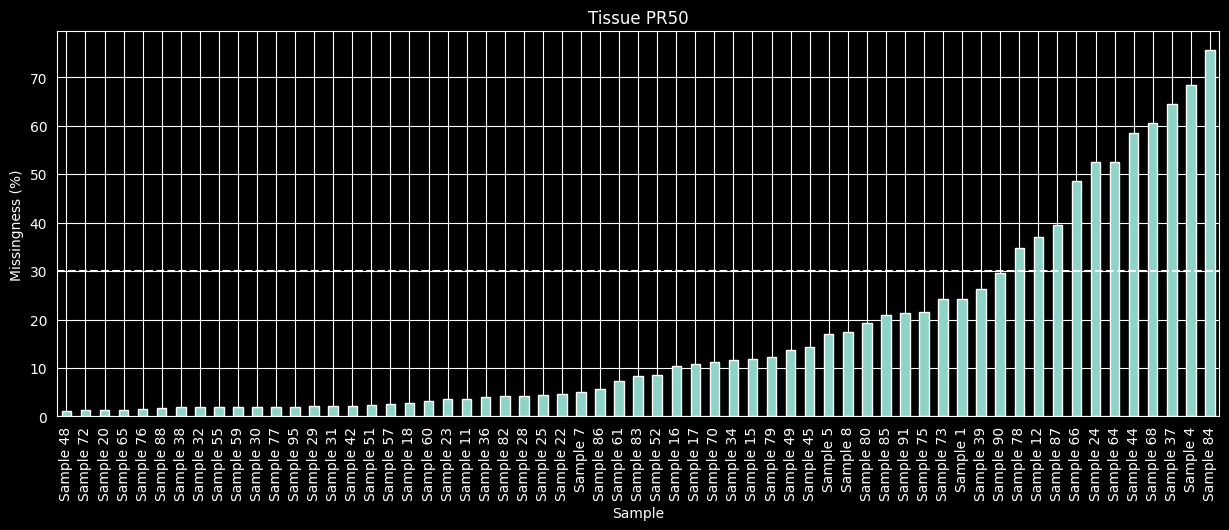

In [20]:
missing_PR50.sort_values().plot(
    kind="bar",
    figsize=(15,5)
)

plt.axhline(30, linestyle="--")
plt.title('Tissue PR50')
plt.ylabel("Missingness (%)")
plt.xlabel("Sample")
plt.show()

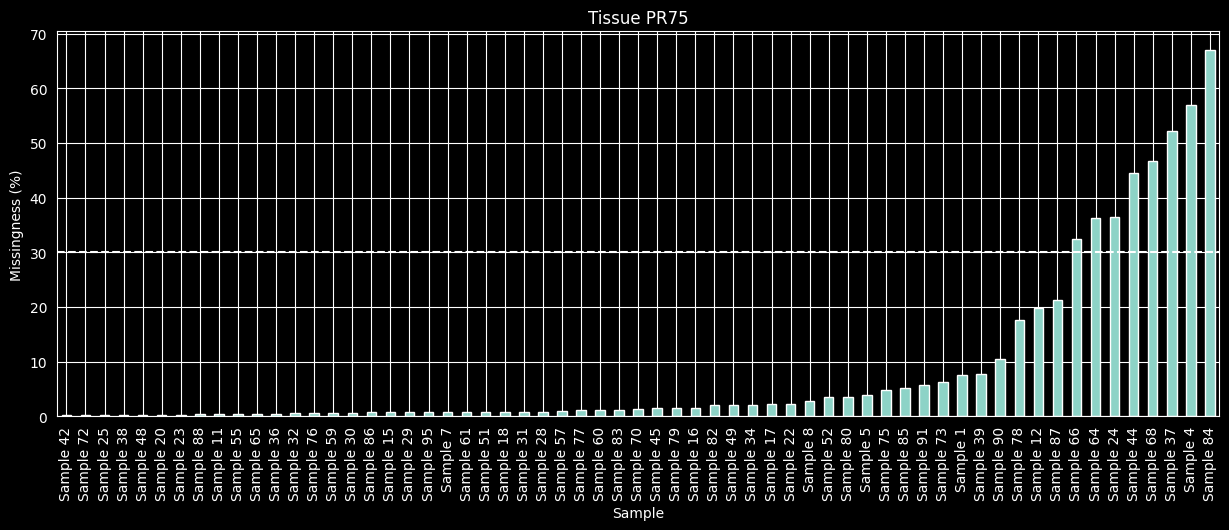

In [21]:
missing_PR75.sort_values().plot(
    kind="bar",
    figsize=(15,5)
)

plt.axhline(30, linestyle="--")
plt.title('Tissue PR75')
plt.ylabel("Missingness (%)")
plt.xlabel("Sample")
plt.show()

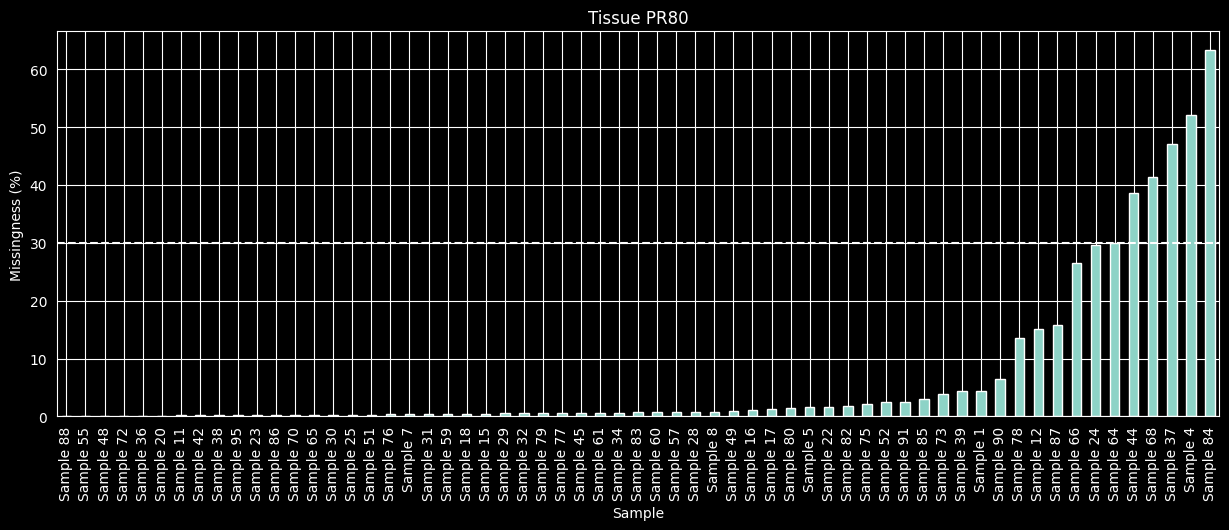

In [22]:

missing_PR80.sort_values().plot(
    kind="bar",
    figsize=(15,5)
)

plt.axhline(30, linestyle="--")
plt.title('Tissue PR80')
plt.ylabel("Missingness (%)")
plt.xlabel("Sample")
plt.show()

In [23]:
PR_plasma = pd.DataFrame({
    "PR50": missing_PR50,
    "PR75": missing_PR75,
    "PR80": missing_PR80
})
PR_plasma= PR_plasma.sort_values(['PR50','PR75','PR80'], ascending=False)
PR_plasma.to_csv('PR_plasma.csv')
PR_plasma.head()

,PR50,PR75,PR80
Sample 84,75.651578,67.043315,63.396624
Sample 4,68.381344,56.967985,52.109705
Sample 37,64.471879,52.165725,47.046414
Sample 68,60.493827,46.704331,41.455696
Sample 44,58.573388,44.444444,38.607595


### Same for Plasma

In [24]:
###### remove samples with missingness > 0.31
to_remove_plasma = ['Sample 84','Sample 4','Sample 37','Sample 68','Sample 44']
to_remove_tissue = ['Sample 95','Sample 91','Sample 8','Sample 80']

plasma_data = plasma_data.drop(to_remove_plasma+to_remove_tissue, axis=1)

print(plasma_data.shape)

(1889, 53)


In [25]:
plasma_data.columns

Index(['Genes', 'Sample 60', 'Sample 65', 'Sample 18', 'Sample 59',
       'Sample 42', 'Sample 30', 'Sample 31', 'Sample 77', 'Sample 32',
       'Sample 7', 'Sample 55', 'Sample 76', 'Sample 28', 'Sample 72',
       'Sample 88', 'Sample 11', 'Sample 64', 'Sample 25', 'Sample 78',
       'Sample 83', 'Sample 70', 'Sample 90', 'Sample 45', 'Sample 85',
       'Sample 17', 'Sample 22', 'Sample 57', 'Sample 66', 'Sample 38',
       'Sample 82', 'Sample 39', 'Sample 61', 'Sample 16', 'Sample 23',
       'Sample 24', 'Sample 87', 'Sample 73', 'Sample 15', 'Sample 49',
       'Sample 75', 'Sample 79', 'Sample 34', 'Sample 1', 'Sample 36',
       'Sample 29', 'Sample 5', 'Sample 86', 'Sample 52', 'Sample 12',
       'Sample 20', 'Sample 51', 'Sample 48'],
      dtype='object')

'
### Global Missingness
Separate features from metadata

In [26]:
gene_symbols = plasma_data['Genes']
expression_matrix = plasma_data.drop(columns=['Genes'])

In [27]:
print("=== Global Missingness ===")
print(f"Total missing values: {expression_matrix.isnull().sum().sum()}")
print(f"Percentage missing: {expression_matrix.isnull().mean().mean()*100:.2f}%")

=== Global Missingness ===
Total missing values: 24390
Percentage missing: 24.83%


### Protein-level missingness


Top 5 proteins with most missing data:
1808    0.981132
750     0.981132
1852    0.981132
991     0.981132
1468    0.962264
1692    0.962264
1830    0.962264
1708    0.962264
1842    0.962264
1893    0.962264
1450    0.962264
1897    0.943396
1547    0.943396
1822    0.943396
215     0.943396
1587    0.943396
1705    0.943396
156     0.943396
1352    0.943396
1716    0.943396
1222    0.943396
1880    0.943396
1621    0.943396
1358    0.924528
842     0.924528
1800    0.924528
1849    0.924528
1817    0.924528
1913    0.924528
1796    0.924528
1679    0.924528
1765    0.924528
369     0.924528
1819    0.905660
536     0.905660
53      0.905660
103     0.905660
1879    0.905660
1460    0.905660
1451    0.905660
1600    0.905660
1858    0.905660
1415    0.886792
1836    0.886792
1856    0.886792
1317    0.886792
1663    0.886792
1212    0.886792
188     0.886792
1561    0.886792
dtype: float64


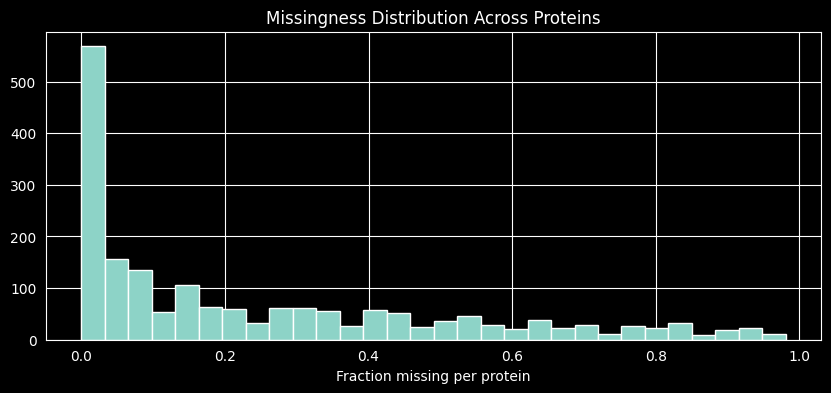

In [60]:
protein_missingness = plasma_data.iloc[:, 1:].isnull().mean(axis=1)
print("\nTop 5 proteins with most missing data:")
print(protein_missingness.sort_values(ascending=False).head(50))

# Visualize
plt.figure(figsize=(10,4))
protein_missingness.hist(bins=30)
plt.title("Missingness Distribution Across Proteins")
plt.xlabel("Fraction missing per protein")
plt.show()

### Patient-Level Missingness

#### Patient-level missingness (only matched data)


Top 10 patients with most missing data:
Sample 24    0.630492
Sample 64    0.629963
Sample 66    0.593436
Sample 87    0.522499
Sample 12    0.493912
Sample 78    0.466384
Sample 90    0.445738
Sample 39    0.412917
Sample 73    0.391742
Sample 85    0.376390
dtype: float64


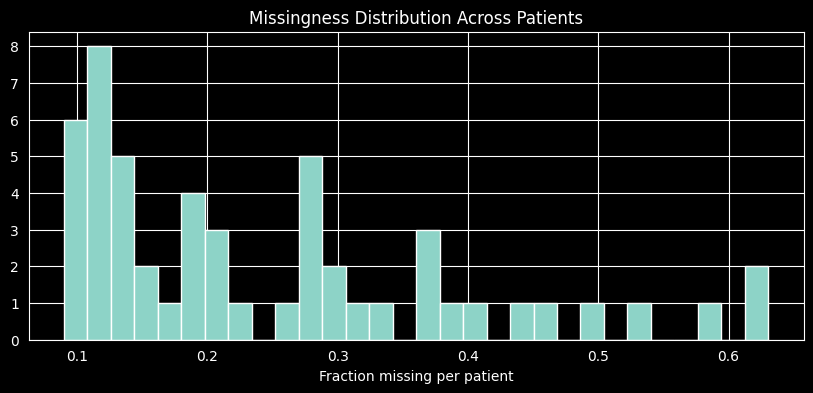

In [28]:

patient_missingness= plasma_data.iloc[:, 1:].isnull().mean(axis=0)
print("\nTop 10 patients with most missing data:")
print(patient_missingness.sort_values(ascending=False).head(10))

plt.figure(figsize=(10,4))
patient_missingness.hist(bins=30)
plt.title("Missingness Distribution Across Patients")
plt.xlabel("Fraction missing per patient")
plt.show()

### Remove Samples with high missingness
Patients with high missingness can artifically inflate protein missingness

Problem is, not the same samples are removed for plasma and tissue proteins

In [29]:
protein_missingness_plasma = plasma_data.iloc[:, 1:].isnull().mean(axis=1)

MIN_DATA_PRESENCE = 0.50
protein_threshold = 1 - MIN_DATA_PRESENCE

good_proteins = protein_missingness_plasma[protein_missingness_plasma <= protein_threshold].index
removed_proteins = protein_missingness_plasma[protein_missingness_plasma > protein_threshold].index.tolist()

plasma_data_filtered = plasma_data.loc[good_proteins]

print(f"\n=== PROTEIN FILTERING PLASMA ===")
print(f"Threshold: ≥{MIN_DATA_PRESENCE:.0%} data presence (≤{protein_threshold:.0%} missing)")
print(f"Removed {len(removed_proteins)} proteins with low data presence")
print(f"Retained {len(good_proteins)} proteins")

plasma_data_filtered.to_excel('plasma_data_protein_filtered_30.xlsx', index=False)



=== PROTEIN FILTERING PLASMA ===
Threshold: ≥50% data presence (≤50% missing)
Removed 357 proteins with low data presence
Retained 1532 proteins


#### Intensity vs Missingness analysis

(1889,)


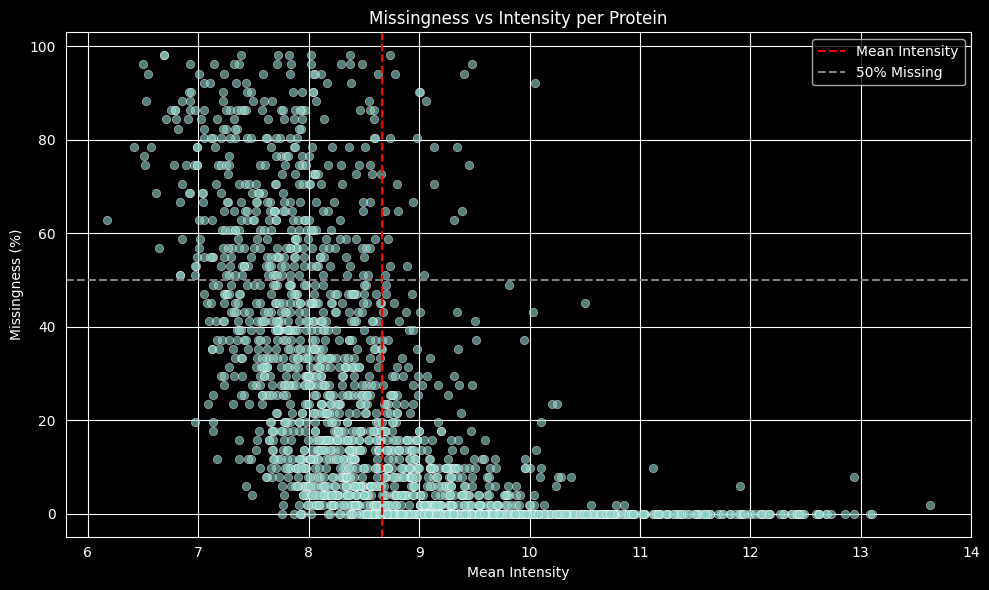

In [30]:

import seaborn as sns
# Compute mean intensity and missing % per protein
expression_data = plasma_data.iloc[:, 2:]
mean_intensity = expression_data.mean(axis=1)
missing_percent = expression_data.isna().sum(axis=1) / expression_data.shape[1] * 100
print(mean_intensity.shape)
# Combine into a DataFrame for plotting
diagnostic_df = pd.DataFrame({
    'mean_intensity': mean_intensity,
    'missing_percent': missing_percent
})

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=diagnostic_df, x='mean_intensity', y='missing_percent', alpha=0.6)

# Add vertical line: mean of mean intensities
plt.axvline(diagnostic_df['mean_intensity'].mean(), color='red', linestyle='--', label='Mean Intensity')

# Add horizontal line at 50% missingness
plt.axhline(50, color='gray', linestyle='--', label='50% Missing')

plt.xlabel('Mean Intensity')
plt.ylabel('Missingness (%)')
plt.title('Missingness vs Intensity per Protein')
plt.legend()
plt.tight_layout()
plt.show()


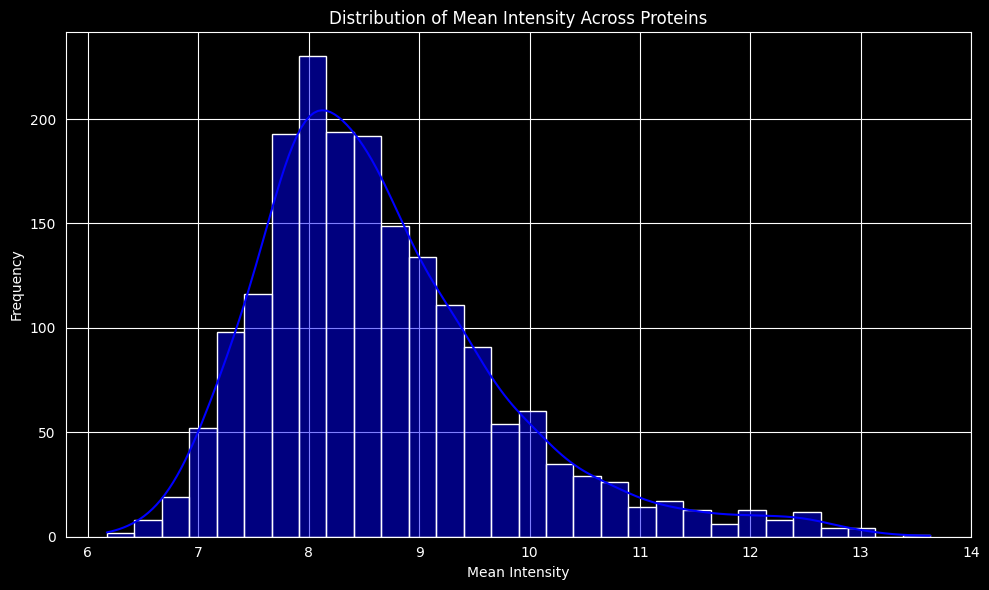

In [31]:
# Plot the histogram of mean intensity values
expression_data = plasma_data.iloc[:, 2:]
mean_intensity = expression_data.mean(axis=1)
plt.figure(figsize=(10, 6))
sns.histplot(mean_intensity, kde=True, color='blue', bins=30)

# Add labels and title
plt.title('Distribution of Mean Intensity Across Proteins')
plt.xlabel('Mean Intensity')
plt.ylabel('Frequency')

# Show the plot
plt.tight_layout()
plt.show()


#### Per cohort analysis

In [32]:
cohorts={
    'AAA':['S013','S021','S054','S066','S069','S092','S083','S072','S075','S094','S010','S040','S062','S005','S014','S034','S037','S078','S081','S092','S006','S093'],
    'AAA_Diabetes_Smoker':['S001','S029','S036','S047','S052','S060','S086','S076'],
    'AAA_Diabetes':['S002','S012','S020','S024','S031','S050'],
    'AAA_Diabetes_Metformin_Smoker':['S011','S025','S028','S051','S061','S082','S048','S032','S095'],
    'AAA_Smoker':['S004','S007','S015','S018','S044','S064','S065','S073','S077','S089','S090','S023','S030','S042','S059','S022','S038','S068','S085','S088','S096','S070','S017','S045','S049','S055','S057','S008','S016','S079','S080','S087','S091','S084','S039'],
    'Control': ['S003','S026','S027','S035','S041','S043','S046','S056','S058','S063','S071','S074','S019','S033','S053','S009','S067']
}


In [33]:
plasma_labels = {}
for cohort in cohorts.keys():
    for value in cohorts[cohort]:
       plasma_labels[value] = cohort

plasma_labels = pd.DataFrame(plasma_labels.items(),columns=['Sample','Cohort Name'])
plasma_labels["Sample"] = plasma_labels["Sample"].str.replace(
    r"S0*(\d+)",
    r"Sample \1",
    regex=True
)
plasma_labels.to_csv('plasma_labels.csv', index=False)
plasma_labels.head()

,Sample,Cohort Name
0,Sample 13,AAA
1,Sample 21,AAA
2,Sample 54,AAA
3,Sample 66,AAA
4,Sample 69,AAA


In [34]:
print(len(plasma_labels))

96


In [35]:
plasma_labels = plasma_labels[plasma_labels['Sample'].isin(plasma_data.columns)]

print(len(plasma_labels))

52


In [36]:
print(plasma_labels['Cohort Name'].value_counts())

Cohort Name
AAA_Smoker                       26
AAA_Diabetes_Metformin_Smoker     8
AAA                               7
AAA_Diabetes_Smoker               7
AAA_Diabetes                      4
Name: count, dtype: int64


In [37]:
plasma_labels = plasma_labels.set_index("Sample")
plasma_labels = plasma_labels['Cohort Name']

In [38]:
plasma_data_1 = plasma_data_filtered.set_index("Genes")
expr_t = plasma_data_1.T
#print(expr_t.head())
print(expr_t.shape)
expr_t["cohort"] =  ['AAA' if label in ['AAA', 'AAA_Smoker'] else 'AAA_Diabetes' for label in plasma_labels]
print(expr_t.columns)

missing_by_cohort = expr_t.groupby("cohort").apply(lambda df: df.isna().mean())
#print(missing_by_cohort.head())

missing_by_cohort = missing_by_cohort.T

(52, 1532)
Index([       'A1BG',         'A2M',       'ABCC2',        'ABI1',
            'ABI3BP',       'ACAA1',        'ACAN',        'ACO1',
              'ACP1',        'ACP2',
       ...
               'ZYX',    'cRAP-ALB', 'cRAP-CSN1S1', 'cRAP-CSN1S2',
         'cRAP-CSN2',   'cRAP-CSN3',  'cRAP-KRT15',     'cRAP-TF',
                 nan,      'cohort'],
      dtype='object', name='Genes', length=1533)


/home/bmep/plalfken/tmp/ipykernel_3190232/4148203128.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_cohort = expr_t.groupby("cohort").apply(lambda df: df.isna().mean())


In [39]:
check = expr_t[expr_t['cohort'].isna()]
check.head(
)

Genes,A1BG,A2M,ABCC2,ABI1,ABI3BP,ACAA1,ACAN,ACO1,ACP1,ACP2,...,ZYX,cRAP-ALB,cRAP-CSN1S1,cRAP-CSN1S2,cRAP-CSN2,cRAP-CSN3,cRAP-KRT15,cRAP-TF,NaN,cohort


In [41]:
#Accounted for cohort size
missingness_per_cohort = (
    expr_t
    .groupby('cohort')
    .apply(lambda df: df.isna().sum().sum() / df.size * 100)
)

print("Missingness percentage per cohort:")
print(missingness_per_cohort)


Missingness percentage per cohort:
cohort
AAA             14.188855
AAA_Diabetes    13.008549
dtype: float64


/home/bmep/plalfken/tmp/ipykernel_3190232/3281313481.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  expr_t


In [42]:
expr = expr_t.drop(columns='cohort')
contingency = pd.DataFrame({
    "Missing": expr.groupby(expr_t["cohort"]).apply(lambda x: x.isna().sum().sum()),
    "Observed": expr.groupby(expr_t["cohort"]).apply(lambda x: x.notna().sum().sum())
})

print(contingency)

              Missing  Observed
cohort                         
AAA              7178     43378
AAA_Diabetes     3789     25319


In [44]:
from scipy.stats import chi2_contingency

G, p, dof, expected = chi2_contingency(
    contingency
)

print(f"G = {G:.2f}")
print(f"p = {p:.3e}")

G = 21.61
p = 3.347e-06


In [45]:
print(plasma_data_1.shape)

(1532, 52)


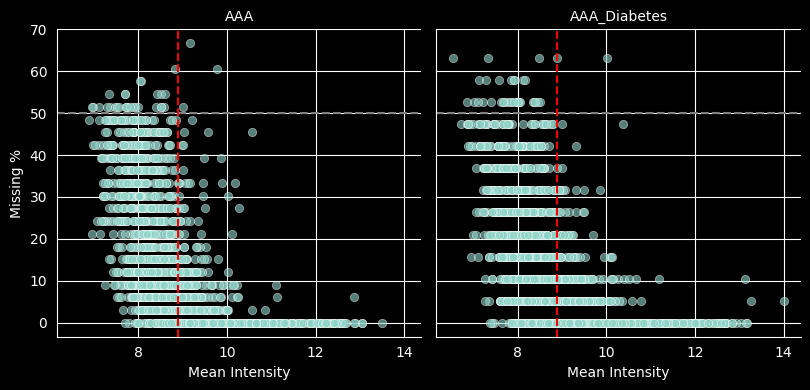

In [46]:
expression_T = plasma_data_1.T.copy().reset_index(drop=True)

expression_T['cohort'] = ['AAA' if label in ['AAA', 'AAA_Smoker'] else 'AAA_Diabetes' for label in plasma_labels]

long_df = expression_T.melt(id_vars='cohort', var_name='protein', value_name='intensity')

summary_df = (
    long_df
    .groupby(['protein', 'cohort'])
    .agg(
        mean_intensity=('intensity', 'mean'),
        missing_percent=('intensity', lambda x: x.isna().mean() * 100)
    )
    .reset_index()
)

g = sns.FacetGrid(
    summary_df,
    col="cohort",
    col_wrap=3,
    sharex=True,
    sharey=True,
    height=4
)

g.map_dataframe(
    sns.scatterplot,
    x='mean_intensity',
    y='missing_percent',
    alpha=0.6
)

for ax in g.axes.flat:
    ax.axhline(50, color='gray', linestyle='--')
    ax.axvline(summary_df['mean_intensity'].mean(), color='red', linestyle='--')

g.set_axis_labels("Mean Intensity", "Missing %")
g.set_titles(col_template="{col_name}")

plt.tight_layout()
plt.show()

In [47]:
expr_t.head()

Genes,A1BG,A2M,ABCC2,ABI1,ABI3BP,ACAA1,ACAN,ACO1,ACP1,ACP2,...,ZYX,cRAP-ALB,cRAP-CSN1S1,cRAP-CSN1S2,cRAP-CSN2,cRAP-CSN3,cRAP-KRT15,cRAP-TF,NaN,cohort
Sample 60,8.322154,10.209880,NaN,9.522192,8.738590,8.118170,9.262258,7.846159,9.042061,7.813172,...,12.543399,10.751366,8.308595,8.441868,8.662909,8.250607,10.563548,10.207682,12.684098,AAA
Sample 65,8.992034,10.430019,NaN,11.121612,8.625304,8.207746,9.062194,7.107217,8.129616,8.620557,...,11.360605,11.112853,9.373957,7.805118,8.078076,7.810549,11.356343,10.312812,12.241342,AAA
Sample 18,9.124551,9.458293,NaN,10.041521,8.326180,8.421102,8.871468,8.816650,9.792732,8.532951,...,12.760279,11.534293,8.125333,8.358366,8.272247,7.545001,11.237416,11.305074,12.288905,AAA
Sample 59,9.013122,10.465531,NaN,10.699718,8.648759,7.835514,9.212572,7.011922,8.260615,7.979522,...,11.363405,11.115686,9.378473,8.194585,NaN,8.085615,11.476868,10.418882,12.711493,AAA
Sample 42,9.469510,10.584158,7.902051,10.336407,8.694532,7.963795,8.485361,7.865797,8.363222,8.154916,...,12.350335,11.563450,8.991502,8.180374,8.334320,7.801571,11.447413,11.626225,12.107409,AAA


#### Check for MAR

In [49]:
from scipy.stats import chi2_contingency
expression_T = plasma_data_1.T.copy().reset_index(drop=True)
expression_T["cohort"] = plasma_labels.values

expression_T['cohort'] = ['AAA' if label in ['AAA', 'AAA_Smoker'] else 'AAA_Diabetes' for label in plasma_labels]

In [50]:
expression_T['cohort'].value_counts()

cohort
AAA             33
AAA_Diabetes    19
Name: count, dtype: int64

In [51]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

expression_T = plasma_data_1.T.copy().reset_index(drop=True)
expression_T["cohort"] = plasma_labels.values

expression_T['cohort'] = ['AAA' if label in ['AAA', 'AAA_Smoker'] else 'AAA_Diabetes' for label in plasma_labels]

long_df = expression_T.melt(
    id_vars="cohort",
    var_name="protein",
    value_name="intensity"
)

long_df["missing"] = long_df["intensity"].isna()
protein_detection = (
    long_df
    .groupby("protein")["missing"]
    .apply(lambda x: (~x).mean())
)

g_test_results = []


for idx, protein in enumerate(long_df['protein'].unique()):

    protein_data = long_df[long_df['protein'] == protein]

    contingency_table = pd.crosstab(
    protein_data["missing"],
    protein_data["cohort"]
)
    missing_rates = (
    protein_data
    .groupby("cohort")["missing"]
    .mean()
)

    print(f"Contingency Table for Protein {protein} (Index {idx}):")
    print(contingency_table)

    if contingency_table.shape[0] < 2: # If 100% present or 100% missing
        print(f"Skipping G-test for protein {protein} (Index {idx}) due to 100% present or 100% missing values in a cohort.")
        # Add a record for proteins with no missing data
        g_test_results.append({
            'protein_index': idx,
            'protein': protein,
            'g_statistic': None,
            'p_value': None,
            'comment': 'All present or all missing'
        })
        continue

    g_stat, p_value, _, _ = chi2_contingency(contingency_table, lambda_='log-likelihood')

    g_test_results.append({
        'protein_index': idx,
        'protein': protein,
        'g_statistic': g_stat,
        'p_value': p_value,
        'missing_rate': missing_rates,
        'comment': 'Test performed'
    })



g_test_df = pd.DataFrame(g_test_results)
pvals = g_test_df["p_value"].dropna()

g_test_df.loc[g_test_df["p_value"].notna(), "p_adj"] = (
    multipletests(pvals, method="fdr_bh")[1]
)
g_test_df.to_csv('g_test_results_per_protein_plasma.csv', index=False)

print(g_test_df)

Contingency Table for Protein A1BG (Index 0):
cohort   AAA  AAA_Diabetes
missing                   
False     33            19
Skipping G-test for protein A1BG (Index 0) due to 100% present or 100% missing values in a cohort.
Contingency Table for Protein A2M (Index 1):
cohort   AAA  AAA_Diabetes
missing                   
False     33            19
Skipping G-test for protein A2M (Index 1) due to 100% present or 100% missing values in a cohort.
Contingency Table for Protein ABCC2 (Index 2):
cohort   AAA  AAA_Diabetes
missing                   
False     18             9
True      15            10
Contingency Table for Protein ABI1 (Index 3):
cohort   AAA  AAA_Diabetes
missing                   
False     31            18
True       2             1
Contingency Table for Protein ABI3BP (Index 4):
cohort   AAA  AAA_Diabetes
missing                   
False     33            19
Skipping G-test for protein ABI3BP (Index 4) due to 100% present or 100% missing values in a cohort.
Contingency

In [52]:
from scipy.stats import chi2_contingency

table = pd.crosstab(long_df["missing"], long_df["cohort"])

print(table)

print(chi2_contingency(table, lambda_="log-likelihood"))

cohort     AAA  AAA_Diabetes
missing                     
False    43378         25319
True      7178          3789
Chi2ContingencyResult(statistic=np.float64(21.753140459250176), pvalue=np.float64(3.1008186587234197e-06), dof=1, expected_freq=array([[43596.17307692, 25100.82692308],
       [ 6959.82692308,  4007.17307692]]))


In [53]:
significant = g_test_df[g_test_df['p_value']<0.05]
print(len(significant))

8


         protein  significance
0           A1BG             1
1            A2M             1
2          ABCC2             1
3           ABI1             1
4         ABI3BP             1
...          ...           ...
1527   cRAP-CSN2             1
1528   cRAP-CSN3             1
1529  cRAP-KRT15             1
1530     cRAP-TF             1
1531         NaN             1

[1532 rows x 2 columns]
Proteins with significant missingness association to cohorts:
     protein_index   protein  g_statistic   p_value         comment  \
118            118     ASGR2     4.489099  0.034112  Test performed   
174            174  C1orf198     6.326923  0.011892  Test performed   
235            235      CD46     8.436218  0.003678  Test performed   
295            295    CLNS1A     4.078052  0.043444  Test performed   
394            394     DECR1    18.228959  0.000020  Test performed   
519            519     FITM1     4.078052  0.043444  Test performed   
746            746  IGLV2-14     4.403546  0

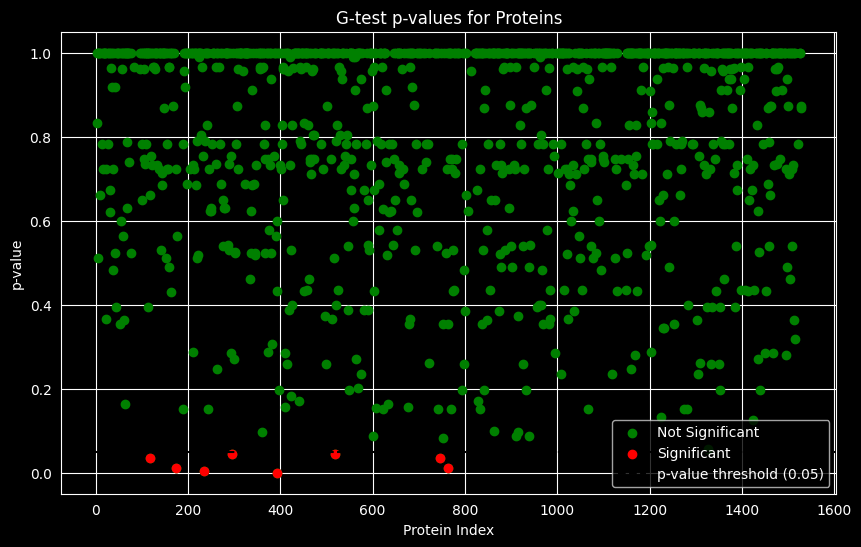

In [54]:

significance_threshold = 0.05

significant_proteins = g_test_df[g_test_df['p_value'] < significance_threshold]
# Adding a new column 'significance' based on the p-value threshold
g_test_df['significance'] = g_test_df['p_value'].apply(lambda x: 2 if x < significance_threshold else 1)

# Save to CSV
g_test_df[['protein', 'significance']].to_csv('proteins_significance_plasma.csv', index=False)

# Print the DataFrame to see the result
print(g_test_df[['protein', 'significance']])
print("Proteins with significant missingness association to cohorts:")
print(significant_proteins)

significant_proteins.to_csv('significant_proteins_plasma.csv', index=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(g_test_df['protein_index'], g_test_df['p_value'], color='green', label='Not Significant')
plt.scatter(significant_proteins['protein_index'], significant_proteins['p_value'], color='red', label='Significant')

plt.axhline(y=0.05, color='black', linestyle='--', label="p-value threshold (0.05)")

plt.xlabel('Protein Index')
plt.ylabel('p-value')
plt.title('G-test p-values for Proteins')
plt.legend()
plt.show()

(1889,)


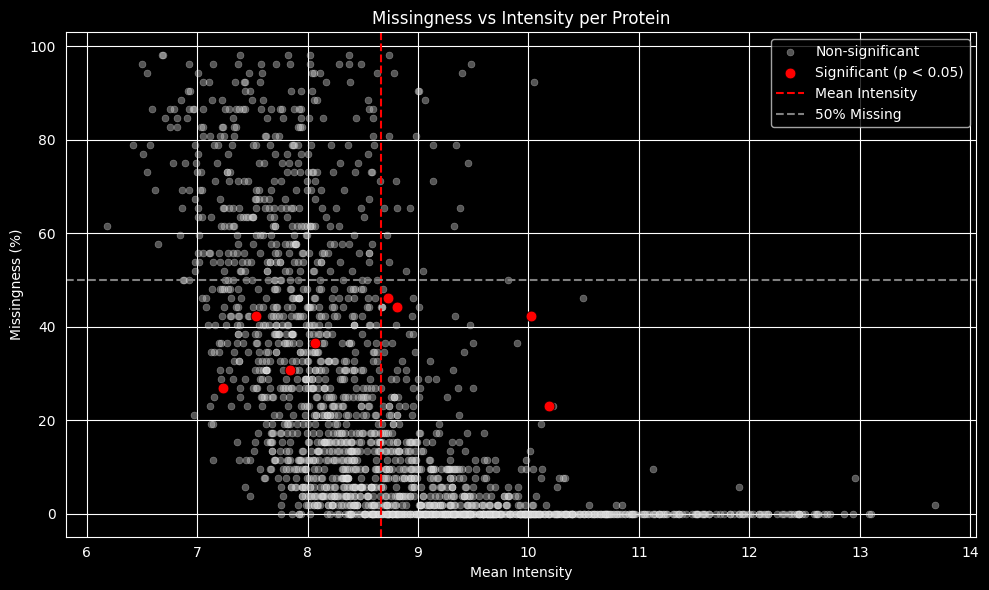

In [56]:
#### look at protein level intensity vs missingness 
import seaborn as sns

# Compute mean intensity and missing % per protein
expression_data = plasma_data.iloc[:, 1:]
mean_intensity = expression_data.mean(axis=1)
missing_percent = expression_data.isna().sum(axis=1) / expression_data.shape[1] * 100
print(mean_intensity.shape)
# Combine into a DataFrame for plotting
diagnostic_df = pd.DataFrame({
    'protein':plasma_data["Genes"],
    'mean_intensity': mean_intensity,
    'missing_percent': missing_percent
})
# Mark significant proteins
diagnostic_df["Significant"] = diagnostic_df["protein"].isin(significant["protein"])
# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=diagnostic_df[~diagnostic_df["Significant"]],
    x="mean_intensity",
    y="missing_percent",
    color="lightgray",
    alpha=0.4,
    s=25,
    label="Non-significant"
)

# Significant proteins (drawn last)
sns.scatterplot(
    data=diagnostic_df[diagnostic_df["Significant"]],
    x="mean_intensity",
    y="missing_percent",
    color="red",
    alpha=1,
    s=60,
    edgecolor="black",
    linewidth=0.5,
    label="Significant (p < 0.05)"
)

# Add vertical line: mean of mean intensities
plt.axvline(diagnostic_df['mean_intensity'].mean(), color='red', linestyle='--', label='Mean Intensity')

# Add horizontal line at 50% missingness
plt.axhline(50, color='gray', linestyle='--', label='50% Missing')

plt.xlabel('Mean Intensity')
plt.ylabel('Missingness (%)')
plt.title('Missingness vs Intensity per Protein')
plt.legend()
plt.tight_layout()
plt.show()



In [57]:
# Adding a new column 'significance' based on the p-value threshold -> 1 non significant
g_test_df['significance'] = g_test_df['p_value'].apply(lambda x: 2 if x < significance_threshold else 1)

# Save to CSV
g_test_df[['protein', 'significance']].to_csv('proteins_significance_plasma.csv', index=False)

# Print the DataFrame to see the result
print(g_test_df[['protein', 'significance']])

         protein  significance
0           A1BG             1
1            A2M             1
2          ABCC2             1
3           ABI1             1
4         ABI3BP             1
...          ...           ...
1527   cRAP-CSN2             1
1528   cRAP-CSN3             1
1529  cRAP-KRT15             1
1530     cRAP-TF             1
1531         NaN             1

[1532 rows x 2 columns]


In [58]:
non_significant_proteins = g_test_df[g_test_df['significance'] == 1]['protein']
significant_proteins = g_test_df[g_test_df['significance'] == 2]['protein']

In [198]:
import seaborn as sns

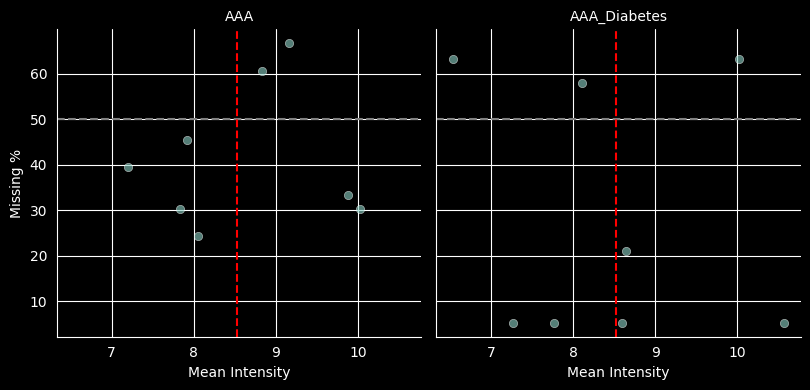

In [59]:
# Filter to only include non-significant proteins
long_df_non_sig = long_df[long_df['protein'].isin(significant_proteins)]

summary_df_non_sig = (
    long_df_non_sig
    .groupby(['protein', 'cohort'])
    .agg(
        mean_intensity=('intensity', 'mean'),
        missing_percent=('intensity', lambda x: x.isna().mean() * 100)
    )
    .reset_index()
)

g = sns.FacetGrid(
    summary_df_non_sig,
    col="cohort",
    col_wrap=3,
    sharex=True,
    sharey=True,
    height=4
)

g.map_dataframe(
    sns.scatterplot,
    x='mean_intensity',
    y='missing_percent',
    alpha=0.6
)

for ax in g.axes.flat:
    ax.axhline(50, color='gray', linestyle='--')
    ax.axvline(summary_df_non_sig['mean_intensity'].mean(), color='red', linestyle='--')

g.set_axis_labels("Mean Intensity", "Missing %")
g.set_titles(col_template="{col_name}")

plt.tight_layout()
plt.show()


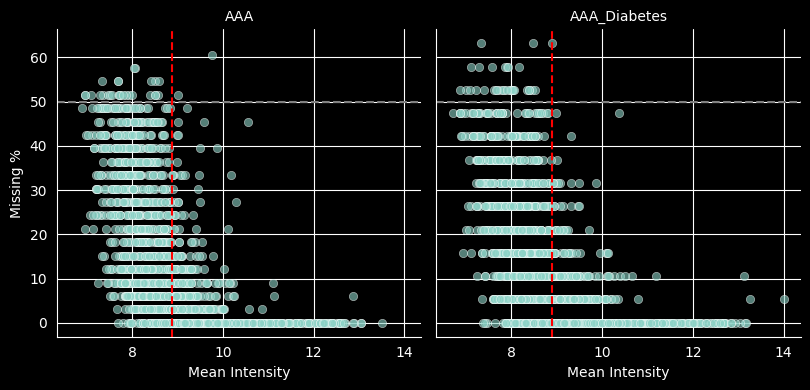

In [60]:
# Filter to only include non-significant proteins
long_df_non_sig = long_df[long_df['protein'].isin(non_significant_proteins)]

summary_df_non_sig = (
    long_df_non_sig
    .groupby(['protein', 'cohort'])
    .agg(
        mean_intensity=('intensity', 'mean'),
        missing_percent=('intensity', lambda x: x.isna().mean() * 100)
    )
    .reset_index()
)

g = sns.FacetGrid(
    summary_df_non_sig,
    col="cohort",
    col_wrap=3,
    sharex=True,
    sharey=True,
    height=4
)

g.map_dataframe(
    sns.scatterplot,
    x='mean_intensity',
    y='missing_percent',
    alpha=0.6
)

for ax in g.axes.flat:
    ax.axhline(50, color='gray', linestyle='--')
    ax.axvline(summary_df_non_sig['mean_intensity'].mean(), color='red', linestyle='--')

g.set_axis_labels("Mean Intensity", "Missing %")
g.set_titles(col_template="{col_name}")

plt.tight_layout()
plt.show()


In [61]:
from scipy.stats import chi2

def little_mcar_test(data):
    # Convert data to numeric and create a mask for missingness
    data = data.apply(pd.to_numeric, errors='coerce')
    missing_mask = data.isnull().astype(int)

    # Calculate means and covariance matrices for complete and incomplete cases
    complete_data = data.dropna()
    incomplete_data = data[~data.index.isin(complete_data.index)]

    n_complete = len(complete_data)
    n_incomplete = len(incomplete_data)

    mean_complete = complete_data.mean()
    mean_incomplete = incomplete_data.mean()

    # Covariance calculation
    cov_complete = complete_data.cov()
    cov_incomplete = incomplete_data.cov()

    # Calculate test statistic
    mean_diff = (mean_incomplete - mean_complete).values.reshape(-1, 1)
    pooled_cov = (n_complete * cov_complete + n_incomplete * cov_incomplete) / (n_complete + n_incomplete)

    test_stat = n_complete * n_incomplete / (n_complete + n_incomplete) * mean_diff.T @ np.linalg.inv(pooled_cov) @ mean_diff
    test_stat = test_stat[0, 0]
    
    # Degrees of freedom
    df = data.shape[1]

    # Calculate p-value
    p_value = 1 - chi2.cdf(test_stat, df)

    print(f"Little's MCAR Test Statistic: {test_stat}")
    print(f"p-value: {p_value}")

    if p_value < 0.05:
        print("MCAR hypothesis rejected. Data may be MAR or MNAR.")
        print("P-value:", np.format_float_scientific(p_value, precision=10))
    else:
        print("MCAR hypothesis not rejected. Data may be MCAR.")
        print("P-value:", np.format_float_scientific(p_value, precision=10))

# Example usage
little_mcar_test(plasma_data_filtered.iloc[:, 1:])

Little's MCAR Test Statistic: 2274.5623665108437
p-value: 0.0
MCAR hypothesis rejected. Data may be MAR or MNAR.
P-value: 0.e+00


Estimated detection threshold (median 5th percentile of high-missing proteins): 7.07


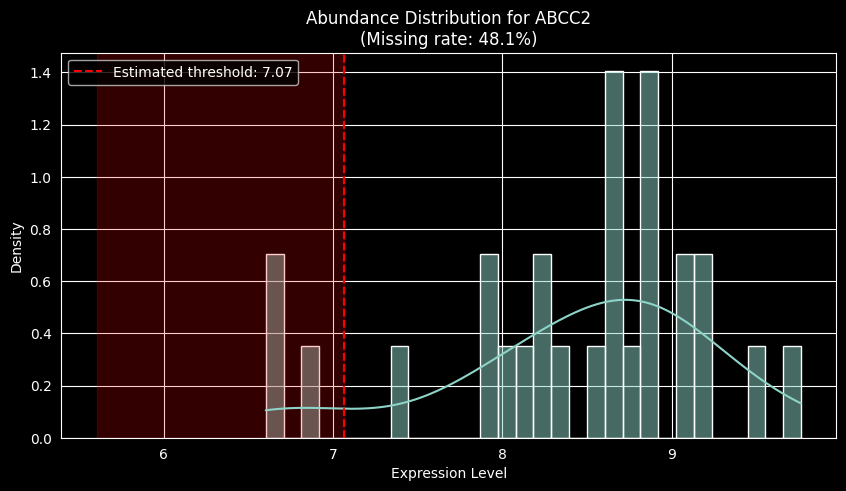

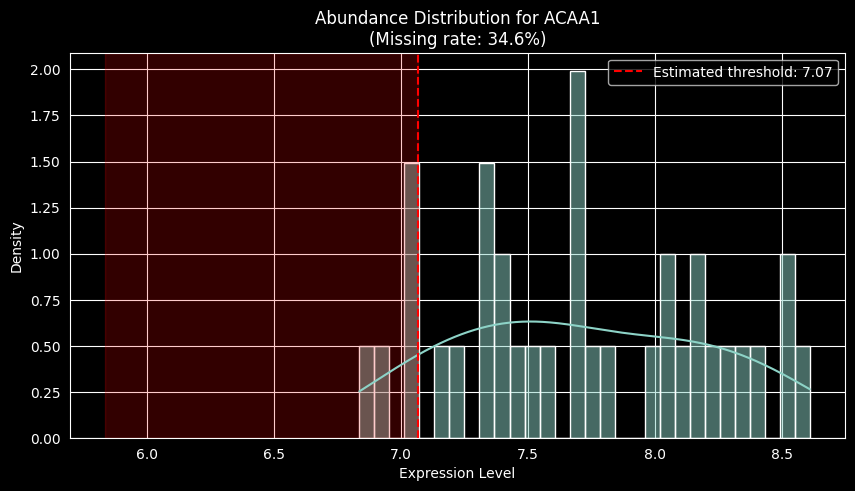

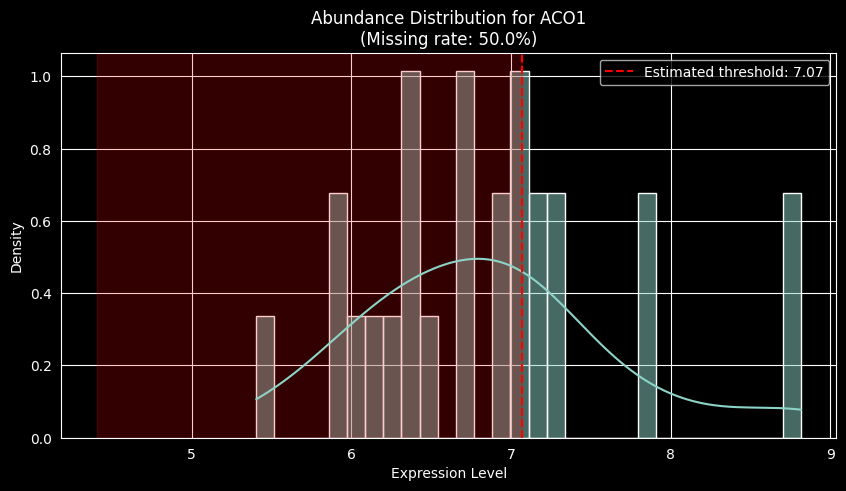

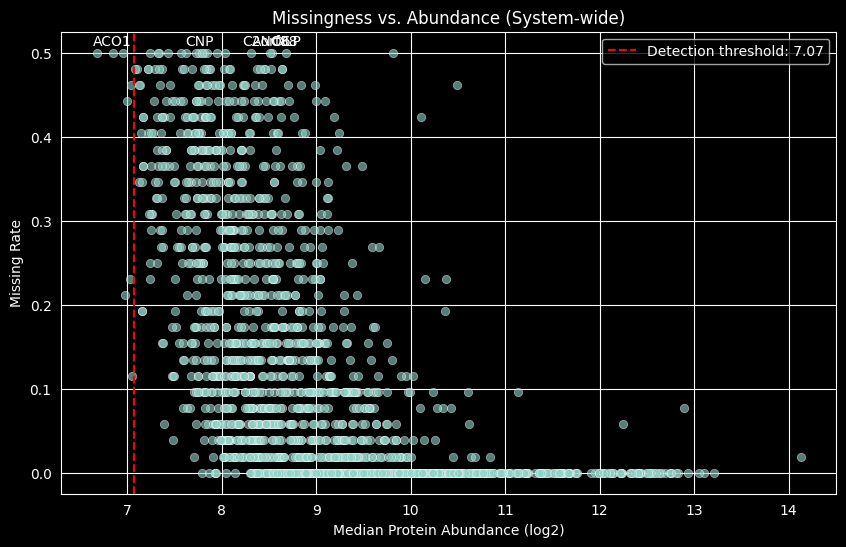

Percentage of missing values that occur when median abundance is below threshold: 0.0%

Interpretation Guide:
- If most missing values occur below 7.07 (high ratio above), MNAR is likely
- If missingness is spread evenly across abundances, consider MAR
- Validate with domain knowledge about your detection technology


In [62]:

# Assuming your data is loaded as df (rows=proteins, columns=patients)
# Column 0 contains gene symbols - set it as index if needed
df = plasma_data_filtered.set_index(plasma_data.columns[0]) if plasma_data.columns[0] == 'Genes' else plasma_data_filtered

# --------------------------------------
# STEP 1: Calculate missingness rates
# --------------------------------------
missing_rates = df.isnull().mean(axis=1)  # Protein-wise missingness
high_missing_proteins = missing_rates[missing_rates > 0.1].index  # Focus on proteins with >10% missingness

# --------------------------------------
# STEP 2: Estimate detection threshold
# --------------------------------------
def estimate_detection_threshold(df, high_missing_proteins, percentile=5):
    """Estimate detection threshold using lowest reliable measurements"""
    low_abundances = []
    for protein in high_missing_proteins:
        observed_values = df.loc[protein].dropna()
        if len(observed_values) > 0:
            low_abundances.append(np.percentile(observed_values, percentile))
    return np.median(low_abundances)

detection_threshold = estimate_detection_threshold(df, high_missing_proteins)
print(f"Estimated detection threshold (median {5}th percentile of high-missing proteins): {detection_threshold:.2f}")

# --------------------------------------
# STEP 3: Visualization (Validation)
# --------------------------------------
def plot_threshold_validation(df, protein, threshold):
    """Plot abundance distribution with threshold line"""
    observed = df.loc[protein].dropna()
    
    plt.figure(figsize=(10, 5))
    sns.histplot(observed, bins=30, kde=True, stat='density')
    plt.axvline(threshold, color='red', linestyle='--', 
                label=f'Estimated threshold: {threshold:.2f}')
    
    # Add shaded area for likely missing values
    plt.axvspan(observed.min() - 1, threshold, alpha=0.2, color='red')
    
    plt.title(f'Abundance Distribution for {protein}\n(Missing rate: {missing_rates[protein]:.1%})')
    plt.xlabel('Expression Level')
    plt.legend()
    plt.show()

# Plot for top 3 high-missing proteins
for protein in high_missing_proteins[:3]:
    plot_threshold_validation(df, protein, detection_threshold)

# --------------------------------------
# STEP 4: System-wide missingness analysis
# --------------------------------------
plt.figure(figsize=(10, 6))
median_abundances = df.median(axis=1)
sns.scatterplot(x=median_abundances, y=missing_rates, alpha=0.6)
plt.axvline(detection_threshold, color='red', linestyle='--', 
            label=f'Detection threshold: {detection_threshold:.2f}')

# Annotate proteins with highest missingness
for protein in missing_rates.nlargest(5).index:
    plt.annotate(protein, (median_abundances[protein], missing_rates[protein]),
                 textcoords="offset points", xytext=(0,5), ha='center')

plt.xlabel('Median Protein Abundance (log2)')
plt.ylabel('Missing Rate')
plt.title('Missingness vs. Abundance (System-wide)')
plt.legend()
plt.show()

# --------------------------------------
# STEP 5: MNAR Assessment
# --------------------------------------
def evaluate_mnar(df, threshold):
    """Quantify how many missing values fall below threshold"""
    missing_below_threshold = 0
    total_missing = df.isnull().sum().sum()
    
    for protein in df.index:
        # Find patients where this protein is missing
        missing_patients = df.columns[df.loc[protein].isnull()]
        
        # For these patients, check other protein abundances
        for patient in missing_patients:
            other_abundances = df[patient].dropna()
            if len(other_abundances) > 0 and other_abundances.median() < threshold:
                missing_below_threshold += 1
                
    return missing_below_threshold / total_missing

mnar_ratio = evaluate_mnar(df, detection_threshold)
print(f"Percentage of missing values that occur when median abundance is below threshold: {mnar_ratio:.1%}")

# --------------------------------------
# Interpretation Guide
# --------------------------------------
print("\nInterpretation Guide:")
print(f"- If most missing values occur below {detection_threshold:.2f} (high ratio above), MNAR is likely")
print("- If missingness is spread evenly across abundances, consider MAR")
print("- Validate with domain knowledge about your detection technology")

Estimated detection threshold (median 5th percentile of high-missing proteins): 7.07


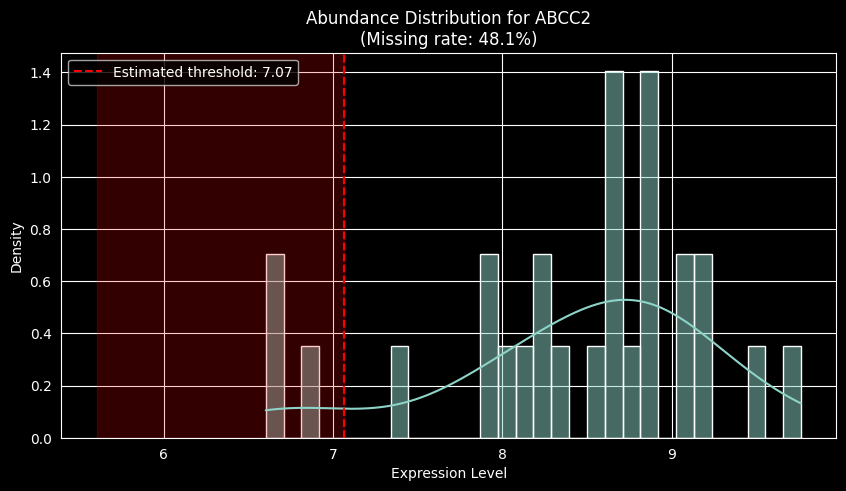

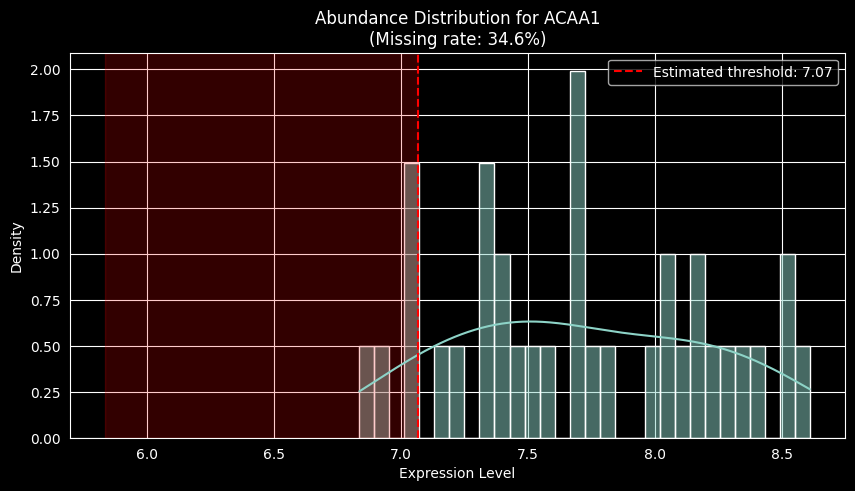

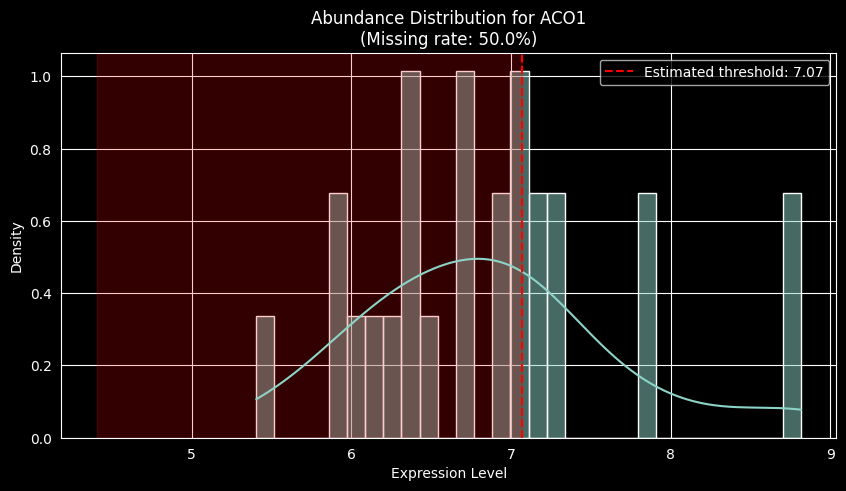

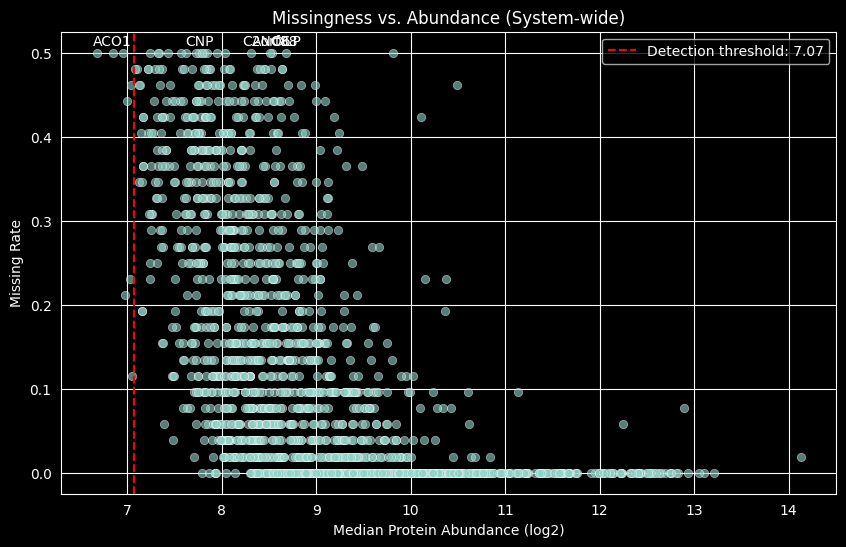

Percentage of missing values that occur when median abundance is below threshold: 0.0%

Interpretation Guide:
- If most missing values occur below 7.07 (high ratio above), MNAR is likely
- If missingness is spread evenly across abundances, consider MAR
- Validate with domain knowledge about your detection technology


In [63]:

# Assuming your data is loaded as df (rows=proteins, columns=patients)
# Column 0 contains gene symbols - set it as index if needed
df = plasma_data_filtered.set_index(plasma_data.columns[0]) if plasma_data.columns[0] == 'Genes' else plasma_data_filtered

# --------------------------------------
# STEP 1: Calculate missingness rates
# --------------------------------------
missing_rates = df.isnull().mean(axis=1)  # Protein-wise missingness
high_missing_proteins = missing_rates[missing_rates > 0.1].index  # Focus on proteins with >10% missingness

# --------------------------------------
# STEP 2: Estimate detection threshold
# --------------------------------------
def estimate_detection_threshold(df, high_missing_proteins, percentile=5):
    """Estimate detection threshold using lowest reliable measurements"""
    low_abundances = []
    for protein in high_missing_proteins:
        observed_values = df.loc[protein].dropna()
        if len(observed_values) > 0:
            low_abundances.append(np.percentile(observed_values, percentile))
    return np.median(low_abundances)

detection_threshold = estimate_detection_threshold(df, high_missing_proteins)
print(f"Estimated detection threshold (median {5}th percentile of high-missing proteins): {detection_threshold:.2f}")

# --------------------------------------
# STEP 3: Visualization (Validation)
# --------------------------------------
def plot_threshold_validation(df, protein, threshold):
    """Plot abundance distribution with threshold line"""
    observed = df.loc[protein].dropna()

    plt.figure(figsize=(10, 5))
    sns.histplot(observed, bins=30, kde=True, stat='density')
    plt.axvline(threshold, color='red', linestyle='--',
                label=f'Estimated threshold: {threshold:.2f}')

    # Add shaded area for likely missing values
    plt.axvspan(observed.min() - 1, threshold, alpha=0.2, color='red')

    plt.title(f'Abundance Distribution for {protein}\n(Missing rate: {missing_rates[protein]:.1%})')
    plt.xlabel('Expression Level')
    plt.legend()
    plt.show()

# Plot for top 3 high-missing proteins
for protein in high_missing_proteins[:3]:
    plot_threshold_validation(df, protein, detection_threshold)

# --------------------------------------
# STEP 4: System-wide missingness analysis
# --------------------------------------
plt.figure(figsize=(10, 6))
median_abundances = df.median(axis=1)
sns.scatterplot(x=median_abundances, y=missing_rates, alpha=0.6)
plt.axvline(detection_threshold, color='red', linestyle='--',
            label=f'Detection threshold: {detection_threshold:.2f}')

# Annotate proteins with highest missingness
for protein in missing_rates.nlargest(5).index:
    plt.annotate(protein, (median_abundances[protein], missing_rates[protein]),
                 textcoords="offset points", xytext=(0,5), ha='center')

plt.xlabel('Median Protein Abundance (log2)')
plt.ylabel('Missing Rate')
plt.title('Missingness vs. Abundance (System-wide)')
plt.legend()
plt.show()

# --------------------------------------
# STEP 5: MNAR Assessment
# --------------------------------------
def evaluate_mnar(df, threshold):
    """Quantify how many missing values fall below threshold"""
    missing_below_threshold = 0
    total_missing = df.isnull().sum().sum()

    for protein in df.index:
        # Find patients where this protein is missing
        missing_patients = df.columns[df.loc[protein].isnull()]

        # For these patients, check other protein abundances
        for patient in missing_patients:
            other_abundances = df[patient].dropna()
            if len(other_abundances) > 0 and other_abundances.median() < threshold:
                missing_below_threshold += 1

    return missing_below_threshold / total_missing

mnar_ratio = evaluate_mnar(df, detection_threshold)
print(f"Percentage of missing values that occur when median abundance is below threshold: {mnar_ratio:.1%}")

# --------------------------------------
# Interpretation Guide
# --------------------------------------
print("\nInterpretation Guide:")
print(f"- If most missing values occur below {detection_threshold:.2f} (high ratio above), MNAR is likely")
print("- If missingness is spread evenly across abundances, consider MAR")
print("- Validate with domain knowledge about your detection technology")


Proteins Below Detection Threshold (High Missingness)
       Gene_Symbol  Median_Abundance  Missingness_Rate
Genes                                                 
TKFC          TKFC          6.673555          0.500000
ACO1          ACO1          6.844186          0.500000
XYLT2        XYLT2          6.949181          0.500000
TNN            TNN          7.033634          0.461538
GXYLT1      GXYLT1          6.992964          0.442308
PEPD          PEPD          7.029729          0.230769
AKAP12      AKAP12          6.970842          0.211538
ITM2B        ITM2B          7.046345          0.115385


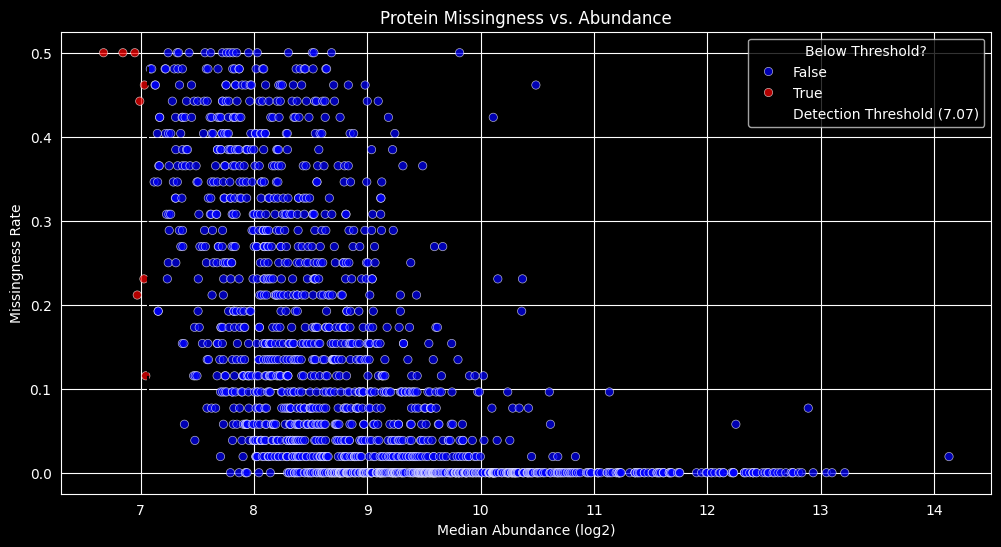

In [64]:
import pandas as pd
import numpy as np
detection_threshold = 7.07

# Assuming:
# - df: Your DataFrame (proteins=rows, patients=columns)
# - detection_threshold: Estimated earlier (e.g., 1.85)

# Calculate key metrics for each protein
protein_stats = pd.DataFrame({
    'Median_Abundance': df.median(axis=1),
    'Missingness_Rate': df.isnull().mean(axis=1),
    'Below_Threshold': df.median(axis=1) < detection_threshold
})



# Sort by missingness (descending) and median abundance (ascending)
protein_stats = protein_stats.sort_values(
    by=['Missingness_Rate', 'Median_Abundance'],
    ascending=[False, True]
)

# Add gene symbols if needed (assuming they're in the index)
protein_stats['Gene_Symbol'] = protein_stats.index

# Filter proteins below threshold with high missingness
high_missing_candidates = protein_stats[
    (protein_stats['Below_Threshold']) & 
    (protein_stats['Missingness_Rate'] > 0.00005)  # Adjust threshold as needed
]

print(f"\n{'='*50}\nProteins Below Detection Threshold (High Missingness)\n{'='*50}")
print(high_missing_candidates[['Gene_Symbol', 'Median_Abundance', 'Missingness_Rate']])

# Save to CSV for review
high_missing_candidates.to_csv("proteins_below_threshold_plasma.csv")

# Visualize the worst offenders
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=protein_stats,
    x='Median_Abundance',
    y='Missingness_Rate',
    hue='Below_Threshold',
    palette={True: 'red', False: 'blue'},
    alpha=0.7
)
plt.axvline(detection_threshold, color='black', linestyle='--', label=f'Detection Threshold ({detection_threshold:.2f})')
plt.title("Protein Missingness vs. Abundance")
plt.xlabel("Median Abundance (log2)")
plt.ylabel("Missingness Rate")
plt.legend(title='Below Threshold?')
plt.show()

In [65]:
from sklearn.mixture import GaussianMixture

all_observed_values = df.values.flatten()  # Convert to 1D array
all_observed_values = all_observed_values[~np.isnan(all_observed_values)]  # Drop NaNs
# Fit GMM to log-transformed abundances (assuming proteomics data)
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(np.log1p(all_observed_values).reshape(-1, 1))

# Threshold = intersection point of the two Gaussians
means = gmm.means_.flatten()
stds = np.sqrt(gmm.covariances_.flatten())
intersection = (means[0] * stds[1] + means[1] * stds[0]) / (stds[0] + stds[1])
global_threshold = np.expm1(intersection)  # Reverse log-transform

print(f"Global threshold (GMM-derived): {global_threshold:.2f}")

Global threshold (GMM-derived): 9.08


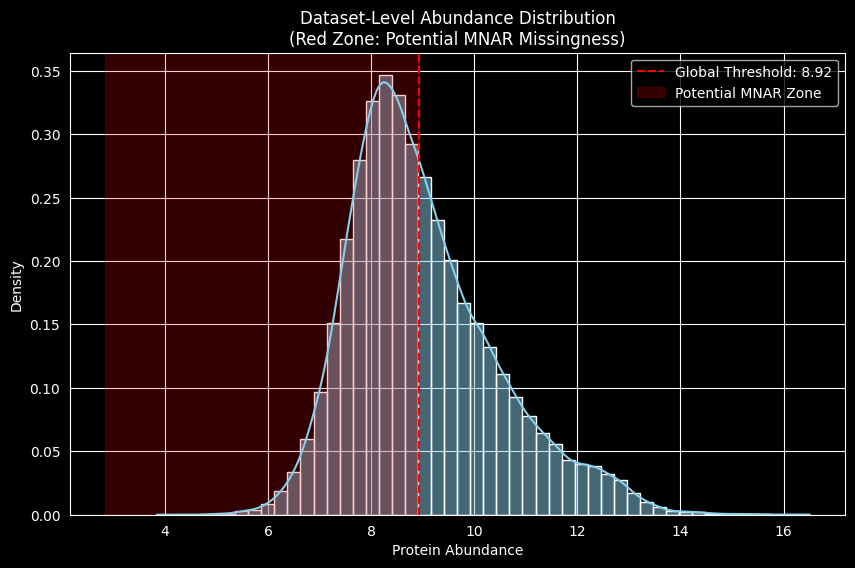

In [66]:

# Flatten all observed values (non-missing)
all_observed_values = df.values.flatten()
all_observed_values = all_observed_values[~np.isnan(all_observed_values)]

# Plot histogram with threshold
plt.figure(figsize=(10, 6))
sns.histplot(all_observed_values, bins=50, kde=True, stat='density', color='skyblue')

# Add global threshold line (GMM-derived: 5.65)
global_threshold = 8.92
plt.axvline(global_threshold, color='red', linestyle='--', 
            label=f'Global Threshold: {global_threshold:.2f}')

# Highlight the "missingness zone" left of the threshold
plt.axvspan(
    xmin=np.min(all_observed_values) - 1, 
    xmax=global_threshold, 
    alpha=0.2, color='red', 
    label='Potential MNAR Zone'
)

plt.xlabel('Protein Abundance')
plt.ylabel('Density')
plt.title('Dataset-Level Abundance Distribution\n(Red Zone: Potential MNAR Missingness)')
plt.legend()
plt.show()

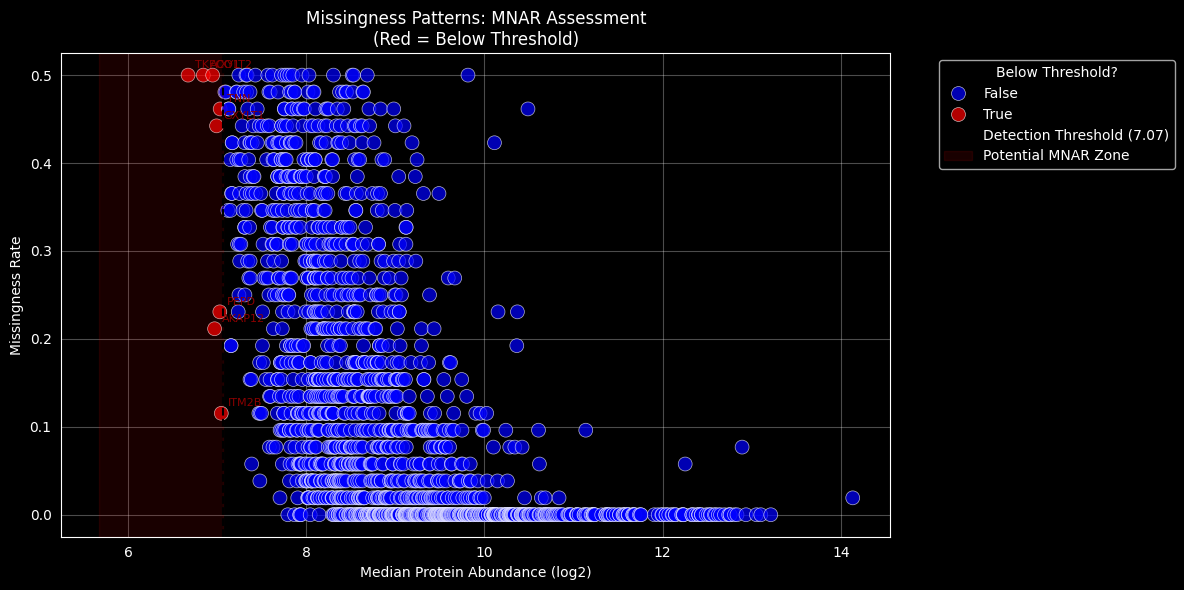

In [67]:

plt.figure(figsize=(12, 6))
#
protein_stats = pd.DataFrame({
    'Median_Abundance': df.median(axis=1),
    'Missingness_Rate': df.isnull().mean(axis=1),
    'Below_Threshold': df.median(axis=1) < detection_threshold
})

# Sort by missingness (descending) and median abundance (ascending)
protein_stats = protein_stats.sort_values(
    by=['Missingness_Rate', 'Median_Abundance'],
    ascending=[False, True]
)

# Add gene symbols if needed (assuming they're in the index)
protein_stats['Gene_Symbol'] = protein_stats.index

# Filter proteins below threshold with high missingness
high_missing_candidates = protein_stats[
    (protein_stats['Below_Threshold']) & 
    (protein_stats['Missingness_Rate'] > 0.00005)  # Adjust threshold as needed
]
#
# Scatter plot with enhanced visuals
scatter = sns.scatterplot(
    data=protein_stats,
    x='Median_Abundance',
    y='Missingness_Rate',
    hue='Below_Threshold',
    palette={True: 'red', False: 'blue'},
    alpha=0.7,
    s=100,  # Larger dots
    edgecolor='w',  # White borders for clarity
    linewidth=0.5
)

# Highlight the detection threshold
plt.axvline(
    x=detection_threshold, 
    color='black', 
    linestyle='--', 
    linewidth=1.5,
    label=f'Detection Threshold ({detection_threshold:.2f})'
)

# Annotate high-missingness proteins
for protein in high_missing_candidates.index:
    plt.annotate(
        protein_stats.loc[protein, 'Gene_Symbol'],
        (protein_stats.loc[protein, 'Median_Abundance'], 
        protein_stats.loc[protein, 'Missingness_Rate']),
        textcoords="offset points",
        xytext=(5, 5),
        ha='left',
        fontsize=8,
        color='darkred'
    )

# Emphasize the "MNAR zone" (left of threshold)
plt.axvspan(
    xmin=protein_stats['Median_Abundance'].min() - 1,
    xmax=detection_threshold,
    alpha=0.1,
    color='red',
    label='Potential MNAR Zone'
)

plt.xlabel('Median Protein Abundance (log2)')
plt.ylabel('Missingness Rate')
plt.title('Missingness Patterns: MNAR Assessment\n(Red = Below Threshold)')
plt.legend(title='Below Threshold?', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [68]:
print(len(high_missing_candidates))

8


In [69]:
high_missing_candidates.head()

,Median_Abundance,Missingness_Rate,Below_Threshold,Gene_Symbol
Genes,,,,
TKFC,6.673555,0.500000,True,TKFC
ACO1,6.844186,0.500000,True,ACO1
XYLT2,6.949181,0.500000,True,XYLT2
TNN,7.033634,0.461538,True,TNN
GXYLT1,6.992964,0.442308,True,GXYLT1


In [70]:
protein_stats.head()

,Median_Abundance,Missingness_Rate,Below_Threshold,Gene_Symbol
Genes,,,,
TKFC,6.673555,0.5,True,TKFC
ACO1,6.844186,0.5,True,ACO1
XYLT2,6.949181,0.5,True,XYLT2
FUCA1,7.243382,0.5,False,FUCA1
UTRN,7.323521,0.5,False,UTRN


In [71]:
print(len(protein_stats[protein_stats['Below_Threshold']]))

8


### Imputation methods

In [72]:
def qrilc_impute(df):
    """
    Apply QRILC imputation.
    Replace this with your QRILC implementation.
    """
    from sklearn.impute import SimpleImputer
    
    # placeholder ONLY
    imp = SimpleImputer(strategy="median")
    return pd.DataFrame(
        imp.fit_transform(df),
        columns=df.columns,
        index=df.index
    )


In [73]:
#### Impute low abundance proteins
#proteins_below_threshold = protein_stats[protein_stats['Below_Threshold']]
plasma_data_filtered = plasma_data_filtered.dropna(subset=["Genes"])
plasma_data_filtered_log = plasma_data_filtered.copy()
plasma_data_filtered_log.iloc[:,1:] = np.log2(
    plasma_data_filtered_log.iloc[:,1:]
)
low_abundance = protein_stats.loc[
    protein_stats["Below_Threshold"],
    "Gene_Symbol"
].tolist()

high_abundance = protein_stats.loc[
    ~protein_stats["Below_Threshold"],
    "Gene_Symbol"
].tolist()
low_abundance_proteins = plasma_data_filtered_log[
    plasma_data_filtered_log['Genes'].isin(low_abundance)]
high_abundance_proteins = plasma_data_filtered_log[plasma_data_filtered_log['Genes'].isin(high_abundance)]



print("Low abundance proteins:", len(low_abundance))
print("High abundance proteins:", len(high_abundance))
print(len(low_abundance_proteins))


Low abundance proteins: 8
High abundance proteins: 1524
8


In [74]:
low_abundance_proteins = low_abundance_proteins.T

In [75]:
low_abundance_proteins.columns = low_abundance_proteins.loc["Genes"]
low_abundance_proteins = low_abundance_proteins.drop(index="Genes")

In [76]:
print(low_abundance_proteins.head())

Genes          ACO1    AKAP12    GXYLT1     ITM2B      PEPD      TKFC  \
Sample 60  2.971987       NaN    2.6116  2.555753  3.042464   3.00047   
Sample 65  2.829285  2.815326  3.036813   2.78425   2.93229  2.848479   
Sample 18  3.140231       NaN  2.710201  2.636997  3.108157  3.116547   
Sample 59   2.80981  2.788449  2.991092  2.770643  2.932131  2.731148   
Sample 42  2.975593  2.838054  2.744971  2.828857   2.95673  2.863515   

Genes           TNN     XYLT2  
Sample 60  2.811868  2.557026  
Sample 65  2.863237  2.842594  
Sample 18       NaN  2.715706  
Sample 59  2.628598       NaN  
Sample 42       NaN  2.613156  


In [77]:

low_imputed = qrilc_impute(low_abundance_proteins)

print(
    "Remaining missing values:",
    low_imputed.isna().sum().sum()
)

Remaining missing values: 0


In [78]:
### split cohort dependent 

print(significant_proteins.isin(low_abundance).any())
cohort_dependent_high = list(
    set(high_abundance)
    .intersection(significant_proteins)
)
non_cohort_high = list(
    set(high_abundance)
    .difference(significant_proteins)
)
high_abundance_proteins_cohort = high_abundance_proteins[high_abundance_proteins['Genes'].isin(cohort_dependent_high)]
print(high_abundance_proteins_cohort.shape)
high_abundance_proteins_no_cohort =  high_abundance_proteins[high_abundance_proteins['Genes'].isin(non_cohort_high)]
print(high_abundance_proteins_no_cohort.shape)

False
(8, 53)
(1515, 53)


In [79]:
print(high_abundance_proteins_cohort.head())

         Genes  Sample 60  Sample 65  Sample 18  Sample 59  Sample 42  \
252      ASGR2        NaN   3.008461        NaN   3.016059   3.036276   
984   C1orf198   3.249111   3.209894   3.232123   3.156044   3.223458   
248       CD46   3.101207   3.111426   3.131419   3.099189   3.064135   
1398    CLNS1A   3.291500   3.456946   3.335003   3.373052        NaN   
728      DECR1   3.302587   3.152868   3.325121   3.228424   3.321541   

      Sample 30  Sample 31  Sample 77  Sample 32  ...  Sample 1  Sample 36  \
252    2.933026   2.998243   3.080864   3.094786  ...  3.024092   3.088812   
984    3.135747   3.183152   3.147961   3.239285  ...       NaN        NaN   
248    3.042299   3.142924   3.118778   3.111795  ...       NaN   2.712810   
1398   3.358231   3.314913   3.430874   3.345830  ...       NaN   3.357859   
728    3.185373   3.305273   3.239287   3.364992  ...       NaN        NaN   

      Sample 29  Sample 5  Sample 86  Sample 52  Sample 12  Sample 20  \
252    2.983729  3.

In [82]:
high_abundance_proteins_cohort.columns

Index(['Genes', 'Sample 60', 'Sample 65', 'Sample 18', 'Sample 59',
       'Sample 42', 'Sample 30', 'Sample 31', 'Sample 77', 'Sample 32',
       'Sample 7', 'Sample 55', 'Sample 76', 'Sample 28', 'Sample 72',
       'Sample 88', 'Sample 11', 'Sample 64', 'Sample 25', 'Sample 78',
       'Sample 83', 'Sample 70', 'Sample 90', 'Sample 45', 'Sample 85',
       'Sample 17', 'Sample 22', 'Sample 57', 'Sample 66', 'Sample 38',
       'Sample 82', 'Sample 39', 'Sample 61', 'Sample 16', 'Sample 23',
       'Sample 24', 'Sample 87', 'Sample 73', 'Sample 15', 'Sample 49',
       'Sample 75', 'Sample 79', 'Sample 34', 'Sample 1', 'Sample 36',
       'Sample 29', 'Sample 5', 'Sample 86', 'Sample 52', 'Sample 12',
       'Sample 20', 'Sample 51', 'Sample 48'],
      dtype='object')

In [81]:
print(high_abundance_proteins_no_cohort.index)

Index([ 761,  198, 1652,   26, 1191, 1488,  861, 1500, 1265,   61,
       ...
         70, 1624, 1238,  309, 1234,  559,  794, 1903, 1760,  267],
      dtype='int64', length=1515)


In [274]:

high_abundance_proteins_no_cohort = high_abundance_proteins_no_cohort.drop(columns="Genes")

In [259]:
high_abundance_proteins_cohort.columns

Index(['Genes', 'Sample 60', 'Sample 65', 'Sample 18', 'Sample 59',
       'Sample 42', 'Sample 30', 'Sample 31', 'Sample 77', 'Sample 32',
       'Sample 7', 'Sample 55', 'Sample 76', 'Sample 28', 'Sample 72',
       'Sample 88', 'Sample 11', 'Sample 64', 'Sample 25', 'Sample 78',
       'Sample 83', 'Sample 70', 'Sample 90', 'Sample 45', 'Sample 85',
       'Sample 17', 'Sample 22', 'Sample 57', 'Sample 66', 'Sample 38',
       'Sample 82', 'Sample 39', 'Sample 61', 'Sample 16', 'Sample 23',
       'Sample 24', 'Sample 87', 'Sample 73', 'Sample 15', 'Sample 49',
       'Sample 75', 'Sample 79', 'Sample 34', 'Sample 1', 'Sample 36',
       'Sample 29', 'Sample 5', 'Sample 86', 'Sample 52', 'Sample 12',
       'Sample 20', 'Sample 51', 'Sample 48'],
      dtype='object')

In [83]:
high_abundance_proteins_cohort = high_abundance_proteins_cohort.T
high_abundance_proteins_no_cohort = high_abundance_proteins_no_cohort.T

In [85]:
high_abundance_proteins_cohort.columns = high_abundance_proteins_cohort.loc['Genes']
#high_abundance_proteins_cohort = high_abundance_proteins_cohort.drop(index="Genes")
high_abundance_proteins_no_cohort.columns = high_abundance_proteins_no_cohort.loc["Genes"]
#high_abundance_proteins_no_cohort = high_abundance_proteins_no_cohort.drop(index="Genes")


In [87]:
high_abundance_proteins_cohort = high_abundance_proteins_cohort.drop(index="Genes")


In [88]:
high_abundance_proteins_no_cohort = high_abundance_proteins_no_cohort.drop(index="Genes")

In [91]:
print(high_abundance_proteins_cohort.head())

Genes         ASGR2  C1orf198      CD46    CLNS1A     DECR1     FITM1  \
Sample 60       NaN  3.249111  3.101207    3.2915  3.302587       NaN   
Sample 65  3.008461  3.209894  3.111426  3.456946  3.152868  2.854361   
Sample 18       NaN  3.232123  3.131419  3.335003  3.325121       NaN   
Sample 59  3.016059  3.156044  3.099189  3.373052  3.228424       NaN   
Sample 42  3.036276  3.223458  3.064135       NaN  3.321541       NaN   

Genes      IGLV2-14  IGLV6-57  
Sample 60  2.939116  2.859342  
Sample 65  3.443685  2.670879  
Sample 18       NaN       NaN  
Sample 59  2.834858  2.737987  
Sample 42  3.594861  2.636124  


In [90]:
#### Random Forest
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.ensemble import RandomForestRegressor

def RF(df):
    rf = RandomForestRegressor(
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    )
    
    imputer = IterativeImputer(
        estimator=rf,
        max_iter=5,
        n_nearest_features = 50,
        random_state=42
    )
    result = imputer.fit_transform(df)
    
    return pd.DataFrame(
            result,
            columns=df.columns,
            index=df.index
        )


In [92]:

high_global_imputed = RF(
    high_abundance_proteins_no_cohort
)

/home/bmep/plalfken/.local/lib/python3.9/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [93]:
print(high_abundance_proteins_cohort)

Genes         ASGR2  C1orf198      CD46    CLNS1A     DECR1     FITM1  \
Sample 60       NaN  3.249111  3.101207    3.2915  3.302587       NaN   
Sample 65  3.008461  3.209894  3.111426  3.456946  3.152868  2.854361   
Sample 18       NaN  3.232123  3.131419  3.335003  3.325121       NaN   
Sample 59  3.016059  3.156044  3.099189  3.373052  3.228424       NaN   
Sample 42  3.036276  3.223458  3.064135       NaN  3.321541       NaN   
Sample 30  2.933026  3.135747  3.042299  3.358231  3.185373  2.809181   
Sample 31  2.998243  3.183152  3.142924  3.314913  3.305273  2.728887   
Sample 77  3.080864  3.147961  3.118778  3.430874  3.239287  2.580419   
Sample 32  3.094786  3.239285  3.111795   3.34583  3.364992  2.717231   
Sample 7   2.972801  3.139904   2.99422       NaN   3.01089  2.771731   
Sample 55       NaN  3.221822  3.099961  3.390525   3.25302  2.780592   
Sample 76  3.091211  3.128529  3.024094  3.394816  3.155654       NaN   
Sample 28       NaN  3.146029   3.08274       NaN  

In [95]:
new_plasma_labels = pd.Series(
    ['AAA' if label in ['AAA', 'AAA_Smoker'] else 'AAA_Diabetes'
     for label in plasma_labels.values],
    index=plasma_labels.index
)

In [96]:
for cohort in set(new_plasma_labels.values):

    samples = new_plasma_labels[
        new_plasma_labels.values== cohort
    ].index

    subset = high_abundance_proteins_cohort.loc[
        samples
    ]

    print(cohort, subset.shape)

AAA (33, 8)
AAA_Diabetes (19, 8)


In [98]:
plasma_T = plasma_data_filtered_log.T
plasma_T.columns = plasma_T.loc['Genes']
plasma_T.drop(index='Genes')
print(plasma_T.head())
print(plasma_T['CD46'])

Genes          A1BG       A2M  ABCC2      ABI1    ABI3BP     ACAA1      ACAN  \
Genes          A1BG       A2M  ABCC2      ABI1    ABI3BP     ACAA1      ACAN   
Sample 60  3.056957  3.351894    NaN  3.251294  3.127401  3.021155  3.211364   
Sample 65  3.168648   3.38267    NaN  3.475294  3.108575  3.036986   3.17986   
Sample 18  3.189754   3.24158    NaN  3.327906  3.057655  3.074009  3.149173   
Sample 59  3.172027  3.387574    NaN  3.419501  3.112493  2.970028  3.203604   

Genes          ACO1      ACP1      ACP2  ...     YWHAZ     ZG16B       ZYX  \
Genes          ACO1      ACP1      ACP2  ...     YWHAZ     ZG16B       ZYX   
Sample 60  2.971987  3.176652  2.965908  ...  3.622697  2.971955  3.648856   
Sample 65  2.829285  3.023187  3.107781  ...  3.743362  3.052767  3.505968   
Sample 18  3.140231  3.291711  3.093045  ...   3.66538  2.928127  3.673588   
Sample 59   2.80981  3.046249  2.996302  ...  3.701518  3.049655  3.506323   

Genes      cRAP-ALB  cRAP-CSN1S1  cRAP-CSN1S2  cRA

In [99]:
high_cohort_imputed = pd.DataFrame(
    index=high_abundance_proteins_cohort.index,
    columns=high_abundance_proteins_cohort.columns
)
for cohort in new_plasma_labels.unique():

    samples = new_plasma_labels[
        new_plasma_labels == cohort
    ].index

    subset = high_abundance_proteins_cohort.loc[
        samples
    ]

    print(cohort, subset.shape)
    print(subset.head())

    imputed_subset = RF(subset)

    high_cohort_imputed.loc[
        samples,
        cohort_dependent_high
    ] = imputed_subset

AAA (33, 8)
Genes         ASGR2  C1orf198      CD46    CLNS1A     DECR1     FITM1  \
Sample                                                                  
Sample 66       NaN       NaN       NaN       NaN       NaN       NaN   
Sample 83       NaN  3.014074  2.724372  3.168738  2.930477       NaN   
Sample 72       NaN  3.088832  3.112073  3.315107  3.383904  2.670952   
Sample 75  3.011885       NaN       NaN  3.282912       NaN  2.828911   
Sample 5   3.105446       NaN       NaN       NaN       NaN  3.216931   

Genes      IGLV2-14  IGLV6-57  
Sample                         
Sample 66   2.85651       NaN  
Sample 83  3.524157  2.882376  
Sample 72  3.555784  2.893901  
Sample 75  3.657817       NaN  
Sample 5    3.36993       NaN  


/home/bmep/plalfken/.local/lib/python3.9/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


AAA_Diabetes (19, 8)
Genes         ASGR2  C1orf198      CD46    CLNS1A     DECR1     FITM1  \
Sample                                                                  
Sample 1   3.024092       NaN       NaN       NaN       NaN  2.924348   
Sample 29  2.983729       NaN  2.988202  3.393453       NaN  3.053573   
Sample 36  3.088812       NaN   2.71281  3.357859       NaN  3.092829   
Sample 52  2.950617       NaN  2.916937  3.340951       NaN  3.425847   
Sample 60       NaN  3.249111  3.101207    3.2915  3.302587       NaN   

Genes      IGLV2-14  IGLV6-57  
Sample                         
Sample 1        NaN  2.893564  
Sample 29  3.685732  2.873254  
Sample 36       NaN  2.956908  
Sample 52  3.516341  2.933057  
Sample 60  2.939116  2.859342  


/home/bmep/plalfken/.local/lib/python3.9/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [100]:
imputed_data = pd.DataFrame(
    index=plasma_data_filtered_log.index
)


imputed_data = pd.concat(
    [
        low_imputed,
        high_global_imputed,
        high_cohort_imputed
    ],
    axis=1
)

In [101]:
imputed_data_1 = imputed_data.T

In [102]:
imputed_data_1.to_excel(r'plasma_data_imputed_30.xlsx')

In [103]:
plasma_data_filtered.to_excel(r'plasma_data_filtered_30.xlsx')

In [106]:
imputed_data.isna().sum().mean()

np.float64(0.0)

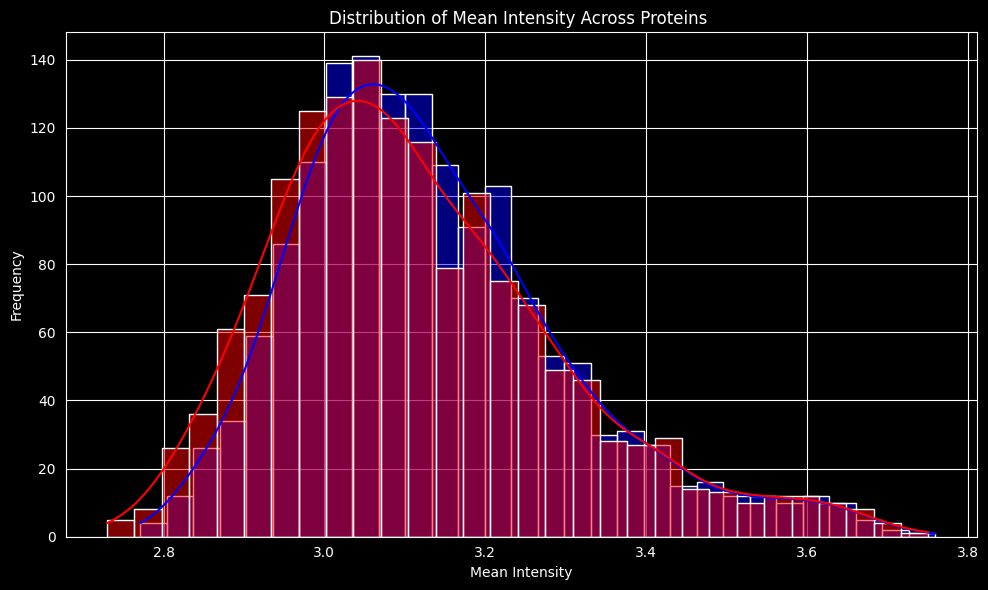

In [110]:

# Plot the histogram of mean intensity values
expression_data = plasma_data_filtered.iloc[:, 1:]
expression_data = np.log2(
    expression_data
)
mean_intensity = expression_data.mean(axis=1)
expression_data_imputed = imputed_data_1.iloc[:, 1:]
mean_intensity_imputed = expression_data_imputed.mean(axis=1)
plt.figure(figsize=(10, 6))
sns.histplot(mean_intensity, kde=True, color='blue', bins=30)
sns.histplot(mean_intensity_imputed, kde=True, color='red', bins=30)

# Add labels and title
plt.title('Distribution of Mean Intensity Across Proteins ')
plt.xlabel('Mean Intensity')
plt.ylabel('Frequency')

# Show the plot
plt.tight_layout()
plt.show()


In [142]:
print(imputed_data_1.loc['AACS'])

Sample 60    3.015783
Sample 65    3.037291
Sample 18    3.005851
Sample 59     3.00443
Sample 42    3.109727
Sample 30    3.018492
Sample 31    3.026754
Sample 77    2.980522
Sample 32    3.039668
Sample 7     3.011826
Sample 55    3.025391
Sample 76    3.063667
Sample 28    3.034614
Sample 72     3.02567
Sample 88    2.992631
Sample 11    3.055376
Sample 64    3.018789
Sample 25    3.116391
Sample 78    3.055736
Sample 83     3.06744
Sample 70    3.067591
Sample 90    3.039927
Sample 45    2.984607
Sample 85     2.95181
Sample 17    3.117198
Sample 22    3.035218
Sample 57    3.012434
Sample 66    3.071067
Sample 38    3.005591
Sample 82     3.01255
Sample 39    3.027632
Sample 61    3.134536
Sample 16    3.007095
Sample 23    3.022468
Sample 24     3.11687
Sample 87    3.018381
Sample 73    2.982307
Sample 15    3.061655
Sample 49    3.032367
Sample 75    3.036077
Sample 79    3.032107
Sample 34    3.000669
Sample 1      3.09389
Sample 36    3.040548
Sample 29    3.136295
Sample 5  

In [139]:
imputed_data_1.shape

(6630, 52)

In [140]:
tissue_data_filtered.shape

(6630, 53)

In [136]:
print(tissue_data_filtered_log.head())

      Genes  Sample 60  Sample 65  Sample 18  Sample 59  Sample 42  Sample 30  \
4936   A1BG   3.377788   3.369656   3.414243   3.654232   3.466397   3.560979   
1610    A2M   3.574198   3.492541   3.515855   3.811213   3.570228   3.675715   
478    AAAS   3.035797   3.151156   2.958886   3.014000   3.172589   2.880006   
4548   AACS        NaN        NaN        NaN        NaN   3.109727        NaN   
1676  AAGAB   2.912066   3.048645   2.912419        NaN   3.069958        NaN   

      Sample 31  Sample 77  Sample 32  ...  Sample 1  Sample 36  Sample 29  \
4936   3.411005   3.333807   3.491348  ...  3.246045   3.290469   3.471365   
1610   3.506992   3.509530   3.804737  ...  3.526674   3.478921   3.590493   
478    3.245340   3.109773        NaN  ...  2.999275   3.115050   3.239854   
4548   3.026754   2.980522        NaN  ...  3.093890   3.040548   3.136295   
1676   3.118930   2.914420   2.790500  ...  2.835447   3.060044   3.162384   

      Sample 5  Sample 86  Sample 52  Sample

In [8]:

print((tissue_data_filtered.iloc[:,1:] == 0).sum().sum())

tissue_data_filtered = tissue_data_filtered.dropna(subset=["Genes"])
tissue_data_filtered_log = tissue_data_filtered.copy()
tissue_data_filtered_log.iloc[:,1:] = np.log2(
    tissue_data_filtered_log.iloc[:,1:]
)
X = tissue_data_filtered_log.set_index("Genes").T


0


In [9]:
X.shape

(52, 4776)

In [140]:
X.head()

Genes,A1BG,A2M,AAAS,AAGAB,AAK1,AAMDC,AAMP,AARS1,AARS2,AARSD1,...,ZSWIM8,ZW10,ZYX,ZZEF1,cRAP-AHSG,cRAP-ALB,cRAP-CSN1S1,cRAP-CSN1S2,cRAP-CSN2,cRAP-KRT15
Sample 60,3.377788,3.574198,3.035797,2.912066,3.004232,3.225550,2.790787,3.144268,3.024580,3.024587,...,2.995110,3.006109,3.251056,2.989769,3.224053,3.320355,3.178333,3.069444,3.099613,3.403457
Sample 65,3.369656,3.492541,3.151156,3.048645,3.113919,3.254301,3.085977,3.214326,3.115745,3.094209,...,3.021665,3.153623,3.207173,3.038774,3.277662,3.491973,3.318719,3.169513,3.218040,3.562665
Sample 18,3.414243,3.515855,2.958886,2.912419,2.999366,3.283590,2.910799,3.147027,3.045716,3.065012,...,2.901059,2.963273,3.276229,3.011386,3.306908,3.510470,3.264553,3.055085,2.977551,3.473757
Sample 59,3.654232,3.811213,3.014000,NaN,3.050185,3.182692,2.988145,3.149742,2.933801,2.988512,...,NaN,2.997920,3.216239,2.952640,3.574016,3.527077,3.098381,3.022068,3.048103,3.277882
Sample 42,3.466397,3.570228,3.172589,3.069958,3.118117,3.288707,3.108714,3.342754,3.189663,3.154134,...,2.979829,3.125417,3.268043,3.018698,3.186576,3.456147,3.324890,3.153692,3.150845,3.499539


In [141]:
X.columns

Index(['A1BG', 'A2M', 'AAAS', 'AAGAB', 'AAK1', 'AAMDC', 'AAMP', 'AARS1',
       'AARS2', 'AARSD1',
       ...
       'ZSWIM8', 'ZW10', 'ZYX', 'ZZEF1', 'cRAP-AHSG', 'cRAP-ALB',
       'cRAP-CSN1S1', 'cRAP-CSN1S2', 'cRAP-CSN2', 'cRAP-KRT15'],
      dtype='str', name='Genes', length=4776)

In [10]:
X_imputed = imputer.fit_transform(X)

KeyboardInterrupt: 

In [ ]:
X_imputed = pd.DataFrame(
    X_imputed,
    index=X.index,
    columns=X.columns)

In [ ]:
X_imputed.to_excel( r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\tissue\tissue_data_imputed_forest.xlsx")

##### MICE imputer


In [95]:
X = tissue_data_filtered_final.iloc[:, 1:].to_numpy().T.astype(np.float32)

In [100]:
from sklearn.impute import IterativeImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.ensemble import ExtraTreesRegressor


gene_symbols = tissue_data_filtered_final.iloc[:, 0].to_numpy()


X = tissue_data_filtered_final.iloc[:, 1:].to_numpy().T.astype(np.float32)  # Transpose for MICE

# =============================================
# 2. Optimized MICE Configuration
# =============================================
imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(
        n_estimators=50,
        max_depth=10,
        n_jobs=-1,
        random_state=42
    ),
    max_iter=20,
    tol=1e-3,
    n_nearest_features=25,
    initial_strategy="median",
    verbose=2,
    random_state=42
)

# =============================================
# 3. Perform MICE Imputation
# =============================================
print("Starting optimized MICE imputation...")
X_imputed = imputer.fit_transform(X)

# =============================================
# 4. Memory-Efficient Reconstruction
# =============================================
df_imputed = pd.DataFrame(
    X_imputed.T,
    columns=tissue_data_filtered_final.columns[1:],
    index=tissue_data_filtered_final.index
).astype(np.float32)

df_imputed.insert(0, 'Gene', gene_symbols)  # Reattach gene symbols

# =============================================
# 5. Save & Evaluate
# =============================================
df_imputed.to_csv("imputed_mice_optimized_cpt.csv", index=False)

missing_mask = np.isnan(X)

print(f"MICE completed in {imputer.n_iter_} iterations")

ImportError: IterativeImputer is experimental and the API might change without any deprecation cycle. To use it, you need to explicitly import enable_iterative_imputer:
from sklearn.experimental import enable_iterative_imputer

##### KNN imputer

In [96]:
from sklearn.impute import KNNImputer
# Grid search parameters
param_grid = {
    'n_neighbors': [10, 25, 50, 75, 100],
    'weights': ['uniform', 'distance']
}

# Initialize KNN imputer
knn_imputer = KNNImputer()

# Placeholder for stability results
stability_results = []

# Number of runs for stability test
n_runs = 10

for n_neighbors in param_grid['n_neighbors']:
    for weights in param_grid['weights']:
        print(f"Trying n_neighbors = {n_neighbors}, weights = {weights}...")

        # Set up the KNN imputer with the current parameters
        imputer = KNNImputer(n_neighbors=n_neighbors, metric='nan_euclidean', weights=weights)

        # Run the imputation multiple times for stability
        imputed_dfs = []
        for _ in range(n_runs):
            X_imputed = imputer.fit_transform(X)  # Assuming X is your input data

            # Store the imputed result for stability check
            imputed_dfs.append(X_imputed)

        # Calculate the variance across the runs
        imputed_dfs_array = np.array(imputed_dfs)
        variance = np.var(imputed_dfs_array, axis=0)  # Calculate variance across the runs

        # Store the variance and configuration in the results
        stability_results.append({
            'n_neighbors': n_neighbors,
            'weights': weights,
            'variance': np.mean(variance)  # Average variance across all features
        })

# Find the configuration with the minimum variance
best_config = min(stability_results, key=lambda x: x['variance'])

print(f"Best configuration (least variance): {best_config}")

# Apply the best imputer configuration
best_imputer = KNNImputer(n_neighbors=best_config['n_neighbors'], metric='nan_euclidean',
                          weights=best_config['weights'])

X_knn_optimized = best_imputer.fit_transform(X)

# Reconstruct DataFrame
df_knn_optimized = pd.DataFrame(X_knn_optimized.T, columns=tissue_data_filtered_final.columns[1:], index=tissue_data_filtered_final.index)
df_knn_optimized.insert(0, 'Gene', gene_symbols)

# Save the optimized result
df_knn_optimized.to_csv("imputed_knn_optimized_stability.csv", index=False)

Trying n_neighbors = 10, weights = uniform...
Trying n_neighbors = 10, weights = distance...
Trying n_neighbors = 25, weights = uniform...
Trying n_neighbors = 25, weights = distance...
Trying n_neighbors = 50, weights = uniform...
Trying n_neighbors = 50, weights = distance...
Trying n_neighbors = 75, weights = uniform...
Trying n_neighbors = 75, weights = distance...
Trying n_neighbors = 100, weights = uniform...
Trying n_neighbors = 100, weights = distance...
Best configuration (least variance): {'n_neighbors': 10, 'weights': 'uniform', 'variance': np.float32(5.2550716e-13)}


##### Hyperimpute Imputation

In [110]:
from hyperimpute.plugins.imputers import Imputers
from sklearn.datasets import load_iris
from hyperimpute.utils.benchmarks import compare_models

imputers = Imputers()

imputers.list()

ImportError: cannot import name 'Sentinel' from 'typing_extensions' (/home/bmep/plalfken/.local/lib/python3.9/site-packages/typing_extensions.py)

In [109]:
proteins = tissue_data_filtered_final.iloc[:, 0]
X = tissue_data_filtered_final.iloc[:, 1:].copy()

X_transposed = X.T.copy()

imputer = Imputers().get("hyperimpute")

X_imputed = imputer.fit_transform(X_transposed)

X_final = X_imputed.T

final_imputed = pd.concat([proteins, pd.DataFrame(X_final, columns=X.columns)], axis=1)

final_imputed.to_csv("imputed_expression.csv", index=False)
print("✅ Imputation complete! Saved as imputed_expression.csv.")

NameError: name 'Imputers' is not defined

In [ ]:
print(f"Selected imputer: {imputer.name()}")

In [ ]:
protein_list = tissue_data_filtered_final.iloc[:, 0].tolist()

# Save the protein list to a CSV file
protein_list_df = pd.DataFrame(protein_list, columns=["Protein"])
protein_list_df.to_csv("protein_list_PRPT.csv", index=False)